# EDA Cartera Sintetica de Seguros (Automotor)

Notebook completo para analizar `polizas_sinteticas.csv` y `siniestros_sinteticos.csv` con estilo `ggplot`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
sns.set_context('notebook')
pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')


In [2]:
base_dir = Path.cwd()
output_dir = base_dir / 'output'

polizas_path = output_dir / 'polizas_sinteticas.csv'
siniestros_path = output_dir / 'siniestros_sinteticos.csv'

if not polizas_path.exists() or not siniestros_path.exists():
    raise FileNotFoundError('No se encontraron CSV en ./output. Ejecuta primero: uv run python main.py')

df_polizas = pd.read_csv(polizas_path, parse_dates=['fecha_inicio_vigencia', 'fecha_fin_vigencia'])
df_siniestros = pd.read_csv(siniestros_path, parse_dates=['fecha_siniestro', 'fecha_denuncia', 'fecha_inicio_juicio'])

print('Polizas:', df_polizas.shape)
print('Siniestros:', df_siniestros.shape)


Polizas: (50000, 31)
Siniestros: (8905, 19)


## 1) EDA de Polizas

Esta sección explora la tabla de **pólizas sintéticas**. Se muestran estadísticas descriptivas, porcentaje de valores faltantes y las distribuciones de las variables más relevantes: plan de cobertura, provincia, zona de riesgo, edad del asegurado, tipo y uso del vehículo, y canal de venta. También se incluye la distribución de las primas por canal. El objetivo es entender la composición de la cartera antes de analizar la siniestralidad.

In [3]:
display(df_polizas.head())
display(df_polizas.describe(include='all').transpose())
display((df_polizas.isna().mean()*100).sort_values(ascending=False).head(20).to_frame('pct_faltante'))


,id_poliza,fecha_inicio_vigencia,fecha_fin_vigencia,numero_poliza,ramo,plan_cobertura,provincia,localidad,barrio,zona_riesgo,edad_asegurado,genero_asegurado,estado_civil,ocupacion,canal_venta,codigo_productor,tiempo_productor_cia_meses,codigo_organizador,comision_pactada,marca_vehiculo,modelo_vehiculo,tipo_vehiculo,anio_vehiculo,suma_asegurada,tipo_uso,es_flota,categoria_cobertura,prima,premio,meses_en_mora,renovada
0,1,2022-01-05,2023-01-05,AUT-2022-000001,Automotor,Todo Riesgo,Buenos Aires,Merlo,San Isidro Centro,Alta,50,M,Divorciado,Comerciante,Broker,PROD-0001,238,NaN,0.10,Ford,Focus,Auto,2015,"6,689,487.51",Particular,False,RC + Casco Total,"578,338.38","691,177.36",0,True
1,2,2023-10-05,2024-10-04,AUT-2023-000002,Automotor,Terceros Completo,Buenos Aires,San Martín,Florencio Varela,Alta,32,M,Soltero,Jubilado,Productor,PROD-0001,230,NaN,0.11,Fiat,Mobi,Auto,2024,"12,075,134.71",Particular,False,RC + Casco Básico,"827,658.10","990,402.38",3,False
2,3,2022-06-29,2023-06-29,AUT-2022-000003,Automotor,Todo Riesgo,Buenos Aires,Campana,NaN,Media,54,M,Divorciado,Comerciante,Organizador,PROD-0011,238,ORG-45,0.18,Fiat,Mobi,Auto,2021,"9,693,444.66",Particular,False,RC + Casco Total,"503,752.90","628,885.15",0,False
3,4,2024-10-15,2025-10-15,AUT-2024-000004,Automotor,Responsabilidad Civil,Buenos Aires,Merlo,Berazategui,Alta,29,M,Divorciado,Empleado,Productor,PROD-0078,222,NaN,0.21,Citroën,Berlingo,Utilitario,2021,"17,502,926.01",Particular,False,Solo RC,"694,011.69","826,793.16",4,True
4,5,2024-11-05,2025-11-05,AUT-2024-000005,Automotor,Responsabilidad Civil,Buenos Aires,Quilmes,Ramos Mejía,Alta,18,M,Soltero,Independiente,Directa,PROD-0064,216,ORG-35,0.00,Renault,Stepway,Auto,2012,"5,333,787.49",Particular,False,Solo RC,"356,528.31","423,164.82",0,True


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id_poliza,"50,000.00",NaN,NaN,NaN,"25,000.50",1.00,"12,500.75","25,000.50","37,500.25","50,000.00","14,433.90"
fecha_inicio_vigencia,50000,NaN,NaN,NaN,2023-01-04 09:08:52.223999,2021-01-01 00:00:00,2022-01-05 00:00:00,2022-12-31 12:00:00,2023-12-27 00:00:00,2024-12-31 00:00:00,NaN
fecha_fin_vigencia,50000,NaN,NaN,NaN,2024-01-04 09:08:52.223999,2022-01-01 00:00:00,2023-01-05 00:00:00,2023-12-31 12:00:00,2024-12-26 00:00:00,2025-12-31 00:00:00,NaN
numero_poliza,50000,50000,AUT-2022-000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ramo,50000,2,Automotor,44074,NaN,NaN,NaN,NaN,NaN,NaN,NaN
plan_cobertura,50000,3,Responsabilidad Civil,20075,NaN,NaN,NaN,NaN,NaN,NaN,NaN
provincia,50000,20,Buenos Aires,17968,NaN,NaN,NaN,NaN,NaN,NaN,NaN
localidad,50000,146,Junín,1155,NaN,NaN,NaN,NaN,NaN,NaN,NaN
barrio,16241,53,Pilar Centro,458,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zona_riesgo,50000,3,Media,17592,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,pct_faltante
barrio,67.52
codigo_organizador,36.95
id_poliza,0.00
tiempo_productor_cia_meses,0.00
meses_en_mora,0.00
premio,0.00
prima,0.00
categoria_cobertura,0.00
es_flota,0.00
tipo_uso,0.00


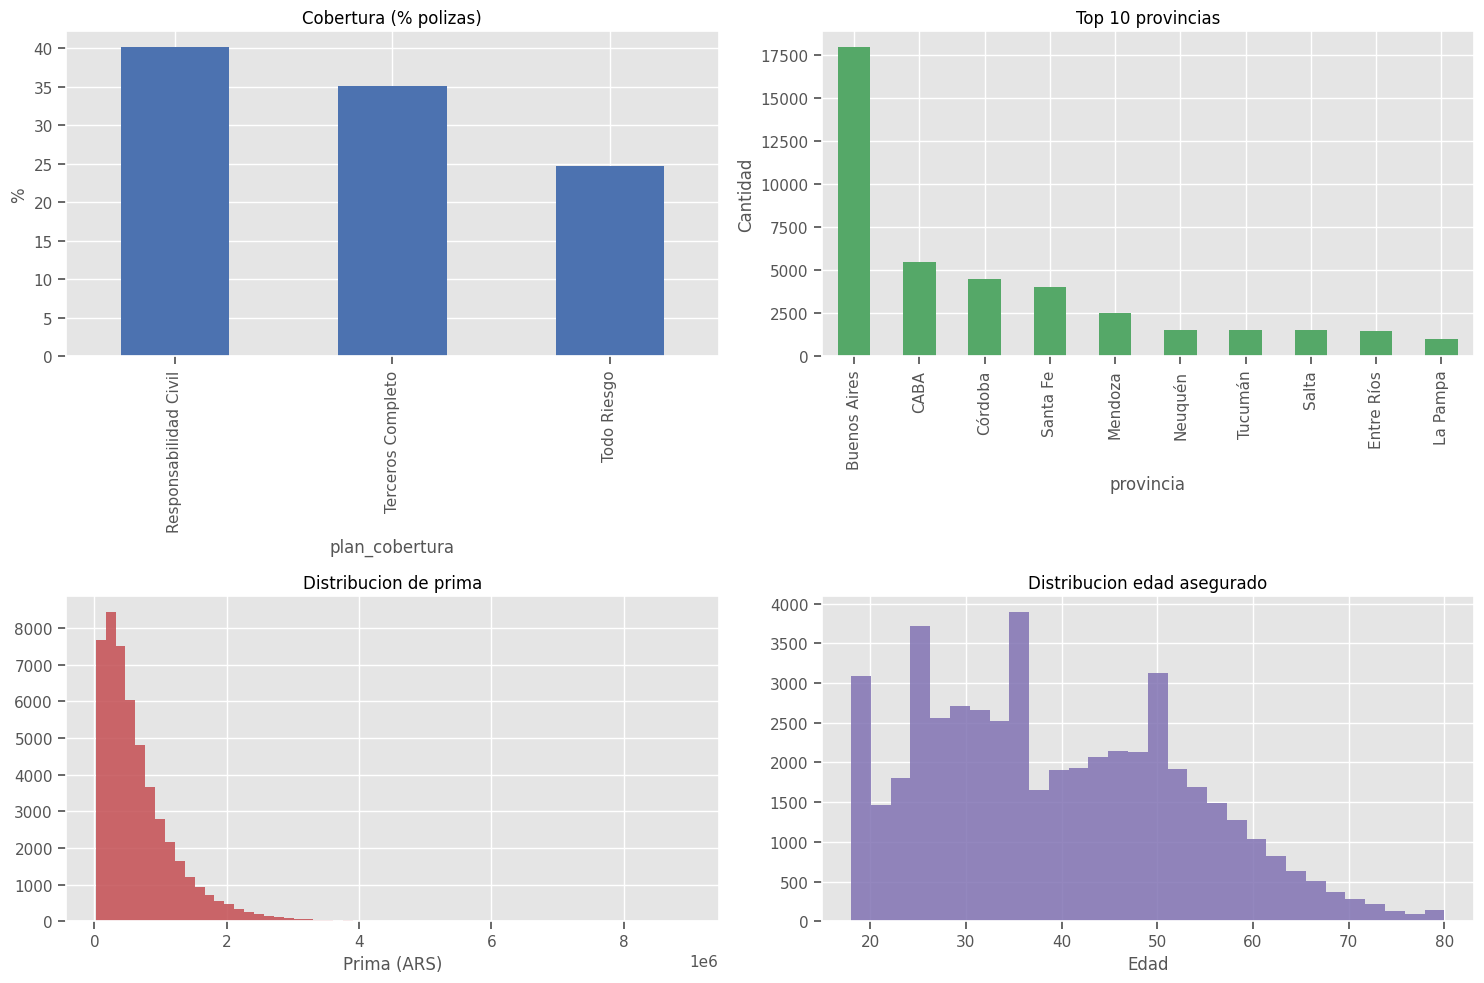

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

(df_polizas['plan_cobertura'].value_counts(normalize=True).mul(100).sort_values(ascending=False)
 .plot(kind='bar', ax=axes[0,0], color='#4c72b0', title='Cobertura (% polizas)'))
axes[0,0].set_ylabel('%')

(df_polizas['provincia'].value_counts().head(10)
 .plot(kind='bar', ax=axes[0,1], color='#55a868', title='Top 10 provincias'))
axes[0,1].set_ylabel('Cantidad')

axes[1,0].hist(df_polizas['prima'], bins=60, color='#c44e52', alpha=0.85)
axes[1,0].set_title('Distribucion de prima')
axes[1,0].set_xlabel('Prima (ARS)')

axes[1,1].hist(df_polizas['edad_asegurado'], bins=30, color='#8172b3', alpha=0.85)
axes[1,1].set_title('Distribucion edad asegurado')
axes[1,1].set_xlabel('Edad')

plt.tight_layout()
plt.show()


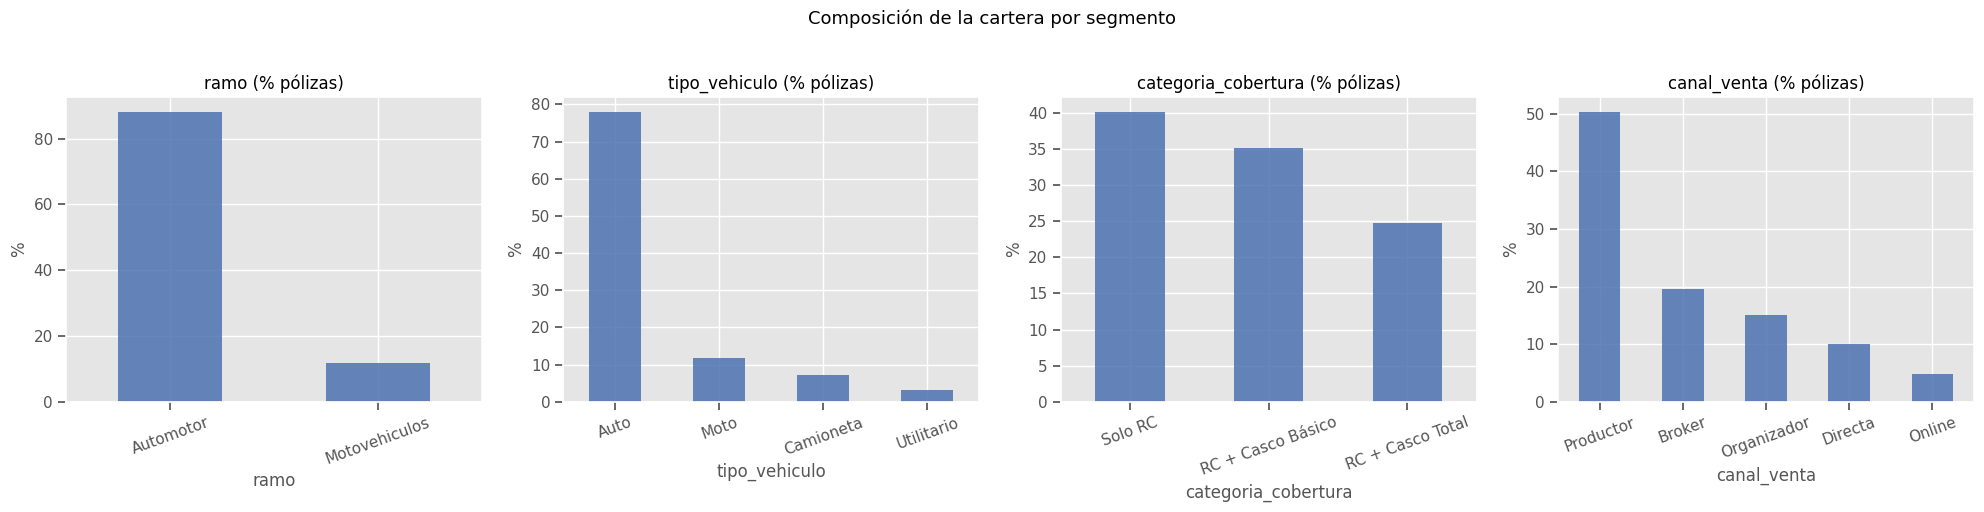

In [5]:

# Nuevas dimensiones de cartera: ramo, tipo_vehiculo, canal y tipo_uso
cols_nuevos = ['ramo', 'tipo_vehiculo', 'categoria_cobertura', 'canal_venta']
cols_disponibles = [c for c in cols_nuevos if c in df_polizas.columns]

if cols_disponibles:
    fig, axes = plt.subplots(1, len(cols_disponibles), figsize=(5 * len(cols_disponibles), 5))
    if len(cols_disponibles) == 1:
        axes = [axes]
    for ax, col in zip(axes, cols_disponibles):
        (df_polizas[col].value_counts(normalize=True).mul(100)
         .sort_values(ascending=False)
         .plot(kind='bar', ax=ax, color='#4c72b0', alpha=0.85))
        ax.set_title(f'{col} (% pólizas)')
        ax.set_ylabel('%')
        ax.tick_params(axis='x', rotation=20)
    plt.suptitle('Composición de la cartera por segmento', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('Regenerar output con el nuevo main.py para ver ramo, tipo_vehiculo y categoria_cobertura.')


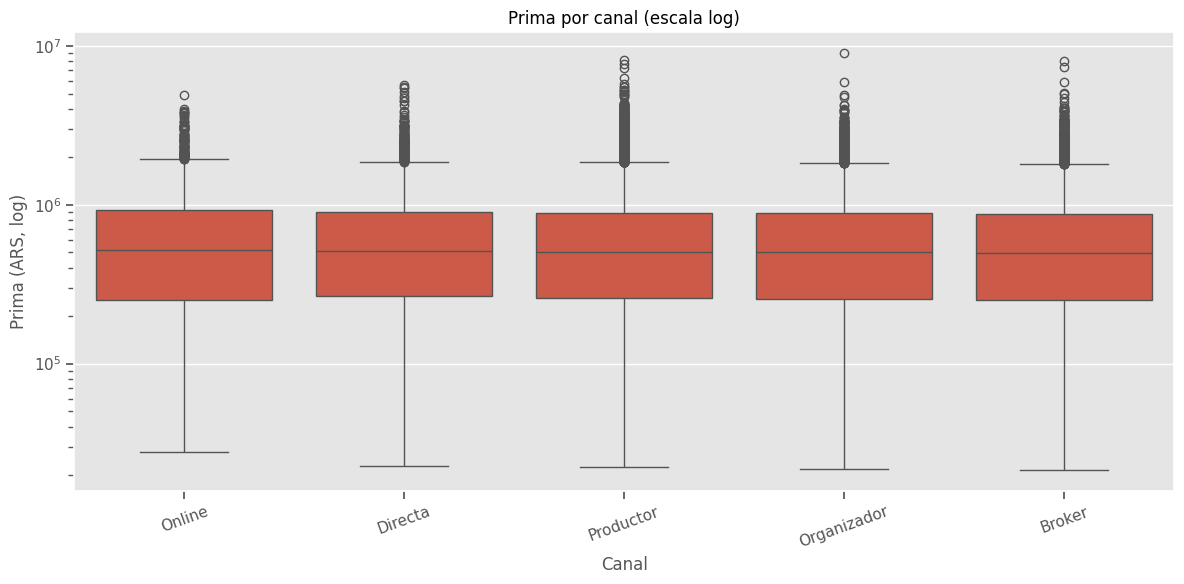

In [6]:
plt.figure(figsize=(12,6))
orden = df_polizas.groupby('canal_venta')['prima'].median().sort_values(ascending=False).index
sns.boxplot(data=df_polizas, x='canal_venta', y='prima', order=orden)
plt.yscale('log')
plt.title('Prima por canal (escala log)')
plt.xlabel('Canal')
plt.ylabel('Prima (ARS, log)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 2) EDA de Siniestros

Esta sección explora la tabla de **siniestros sintéticos**. Se revisan estadísticas básicas, valores faltantes y la distribución del **lag de denuncia** (días entre la fecha del siniestro y su reporte a la aseguradora). También se analiza la distribución por tipo de daño (`tipo_danio`) y los indicadores legales: porcentaje de siniestros en mediación, en juicio y con sentencia. Un lag elevado puede indicar problemas de reserva; un alto porcentaje en juicio señala exposición legal.

In [7]:
display(df_siniestros.head())
display(df_siniestros.describe(include='all').transpose())
display((df_siniestros.isna().mean()*100).sort_values(ascending=False).head(20).to_frame('pct_faltante'))


,id_siniestro,numero_siniestro,id_poliza,ramo,fecha_siniestro,fecha_denuncia,fecha_inicio_juicio,tipo_danio,monto_reclamado,cobertura_casco,cobertura_rc,categoria_siniestro,en_mediacion,en_juicio,con_sentencia,terceros_involucrados,conductor_es_asegurado,bien_recuperado,ubicacion_siniestro
0,1,SIN-2022-000001,11,Automotor,2022-11-20,2022-11-21,NaT,Choque,"374,178.77",True,True,Mixto,False,False,False,True,True,NaN,Buenos Aires
1,2,SIN-2023-000002,11,Automotor,2023-02-02,2023-02-10,NaT,Robo total,"3,899,964.42",True,False,Casco,False,False,False,False,True,False,Buenos Aires
2,3,SIN-2022-000003,16,Automotor,2022-03-25,2022-03-27,NaT,Choque,"1,061,355.33",False,False,Mixto,False,False,False,False,True,NaN,Córdoba
3,4,SIN-2024-000004,30,Motovehiculos,2024-12-15,2024-12-20,NaT,Choque,"1,058,413.50",False,True,RC,False,False,False,True,True,NaN,Buenos Aires
4,5,SIN-2024-000005,30,Motovehiculos,2024-06-11,2024-06-17,NaT,Choque,"560,478.03",False,False,Mixto,False,False,False,False,True,NaN,Buenos Aires


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id_siniestro,"8,905.00",NaN,NaN,NaN,"4,453.00",1.00,"2,227.00","4,453.00","6,679.00","8,905.00","2,570.80"
numero_siniestro,8905,8905,SIN-2022-000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id_poliza,"8,905.00",NaN,NaN,NaN,"25,196.08",11.00,"12,634.00","25,370.00","37,593.00","49,993.00","14,346.19"
ramo,8905,2,Automotor,7192,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fecha_siniestro,8905,NaN,NaN,NaN,2023-07-09 02:09:41.336328,2021-01-07 00:00:00,2022-07-11 00:00:00,2023-07-18 00:00:00,2024-07-10 00:00:00,2025-12-23 00:00:00,NaN
fecha_denuncia,8905,NaN,NaN,NaN,2023-07-14 00:34:26.614261,2021-01-07 00:00:00,2022-07-17 00:00:00,2023-07-24 00:00:00,2024-07-14 00:00:00,2025-12-27 00:00:00,NaN
fecha_inicio_juicio,264,NaN,NaN,NaN,2023-12-21 00:05:27.272727,2021-06-23 00:00:00,2022-12-23 18:00:00,2024-01-01 00:00:00,2024-12-29 18:00:00,2027-04-21 00:00:00,NaN
tipo_danio,8905,7,Choque,3547,NaN,NaN,NaN,NaN,NaN,NaN,NaN
monto_reclamado,"8,905.00",NaN,NaN,NaN,"2,938,871.27","6,956.81","436,809.18","1,162,764.49","3,078,140.78","110,182,580.61","5,370,139.38"
cobertura_casco,8905,2,False,4755,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,pct_faltante
fecha_inicio_juicio,97.04
bien_recuperado,83.25
id_siniestro,0.00
cobertura_rc,0.00
conductor_es_asegurado,0.00
terceros_involucrados,0.00
con_sentencia,0.00
en_juicio,0.00
en_mediacion,0.00
categoria_siniestro,0.00


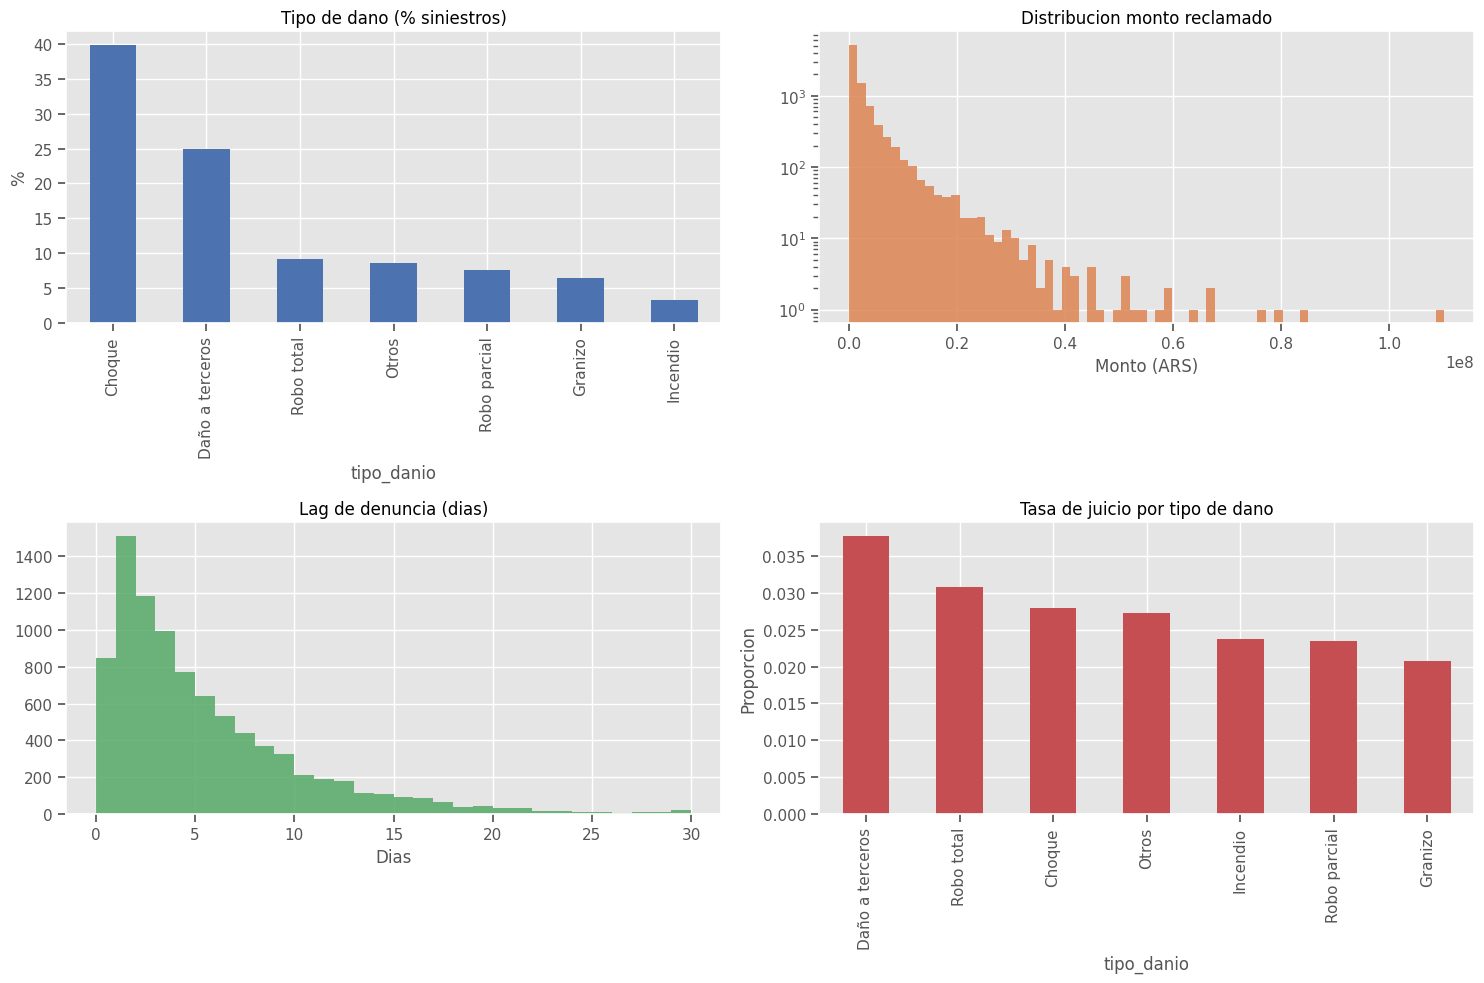

In [8]:
df_siniestros['lag_denuncia_dias'] = (df_siniestros['fecha_denuncia'] - df_siniestros['fecha_siniestro']).dt.days

fig, axes = plt.subplots(2, 2, figsize=(15,10))

(df_siniestros['tipo_danio'].value_counts(normalize=True).mul(100).sort_values(ascending=False)
 .plot(kind='bar', ax=axes[0,0], color='#4c72b0', title='Tipo de dano (% siniestros)'))
axes[0,0].set_ylabel('%')

axes[0,1].hist(df_siniestros['monto_reclamado'], bins=70, color='#dd8452', alpha=0.85)
axes[0,1].set_title('Distribucion monto reclamado')
axes[0,1].set_xlabel('Monto (ARS)')
axes[0,1].set_yscale('log')

axes[1,0].hist(df_siniestros['lag_denuncia_dias'].dropna(), bins=30, color='#55a868', alpha=0.85)
axes[1,0].set_title('Lag de denuncia (dias)')
axes[1,0].set_xlabel('Dias')

juicio_rate = df_siniestros.groupby('tipo_danio')['en_juicio'].mean().sort_values(ascending=False)
juicio_rate.plot(kind='bar', ax=axes[1,1], color='#c44e52', title='Tasa de juicio por tipo de dano')
axes[1,1].set_ylabel('Proporcion')

plt.tight_layout()
plt.show()


## 3) Loss Ratio por Grupos

El **loss ratio (LR)** es la métrica central de rentabilidad: `LR = siniestros_pagados / prima`. Un LR > 1 indica que el segmento pierde dinero. Aquí se calcula el LR por **provincia** (top 10), **plan de cobertura**, **zona de riesgo** y **grupo de edad**. Se espera que zonas de alto riesgo (Alta) tengan LR más elevado, que "Todo Riesgo" concentre más siniestralidad, y que conductores jóvenes (< 25) muestren peor resultado técnico.

In [9]:
siniestros_poliza = (df_siniestros.groupby('id_poliza', as_index=False)['monto_reclamado']
                    .sum().rename(columns={'monto_reclamado':'siniestros_incurridos'}))

df_lr = df_polizas.merge(siniestros_poliza, on='id_poliza', how='left')
df_lr['siniestros_incurridos'] = df_lr['siniestros_incurridos'].fillna(0)
df_lr['loss_ratio_poliza'] = np.where(df_lr['prima'] > 0, df_lr['siniestros_incurridos']/df_lr['prima'], np.nan)

lr_global = df_lr['siniestros_incurridos'].sum() / df_lr['prima'].sum()
print(f'Loss ratio global: {lr_global:.4f} ({lr_global*100:.2f}%)')


Loss ratio global: 0.7900 (79.00%)


In [10]:
def resumen_loss_ratio(df, grupo):
    t = (df.groupby(grupo, as_index=False)
         .agg(polizas=('id_poliza','count'), prima_total=('prima','sum'), siniestros_total=('siniestros_incurridos','sum')))
    t['loss_ratio'] = t['siniestros_total'] / t['prima_total']
    return t.sort_values('loss_ratio', ascending=False)

lr_provincia = resumen_loss_ratio(df_lr, 'provincia')
lr_canal = resumen_loss_ratio(df_lr, 'canal_venta')
lr_cobertura = resumen_loss_ratio(df_lr, 'plan_cobertura')
lr_zona = resumen_loss_ratio(df_lr, 'zona_riesgo')

display(lr_provincia.head(12))
display(lr_canal)
display(lr_cobertura)
display(lr_zona)


,provincia,polizas,prima_total,siniestros_total,loss_ratio
17,Santa Fe,4051,"2,777,850,769.31","2,571,393,526.99",0.93
1,CABA,5503,"4,575,798,240.94","3,966,641,516.97",0.87
0,Buenos Aires,17968,"13,750,464,958.69","11,737,656,634.97",0.85
5,Córdoba,4482,"3,006,913,049.18","2,211,238,468.51",0.74
10,Mendoza,2527,"1,680,664,513.64","1,204,993,423.03",0.72
14,Salta,1513,"710,636,714.02","502,676,080.53",0.71
8,Jujuy,962,"459,697,093.96","324,073,624.51",0.70
15,San Juan,947,"450,587,386.88","306,952,139.09",0.68
19,Tucumán,1535,"730,673,821.55","497,273,592.77",0.68
18,Santiago del Estero,1001,"456,942,518.40","284,478,381.81",0.62


,canal_venta,polizas,prima_total,siniestros_total,loss_ratio
3,Organizador,7553,"4,964,904,712.58","4,153,023,072.96",0.84
0,Broker,9826,"6,432,344,012.29","5,307,128,765.43",0.83
4,Productor,25177,"16,718,481,028.01","12,913,546,551.36",0.77
1,Directa,4998,"3,363,806,308.56","2,559,588,949.75",0.76
2,Online,2446,"1,649,194,030.88","1,237,361,351.19",0.75


,plan_cobertura,polizas,prima_total,siniestros_total,loss_ratio
0,Responsabilidad Civil,20075,"9,321,374,345.44","10,129,870,185.65",1.09
1,Terceros Completo,17560,"12,234,128,813.47","9,144,576,736.30",0.75
2,Todo Riesgo,12365,"11,573,226,933.41","6,896,201,768.74",0.60


,zona_riesgo,polizas,prima_total,siniestros_total,loss_ratio
0,Alta,16939,"14,259,183,346.95","12,899,642,978.11",0.90
2,Media,17592,"11,532,508,184.81","8,792,280,592.36",0.76
1,Baja,15469,"7,337,038,560.56","4,478,725,120.22",0.61


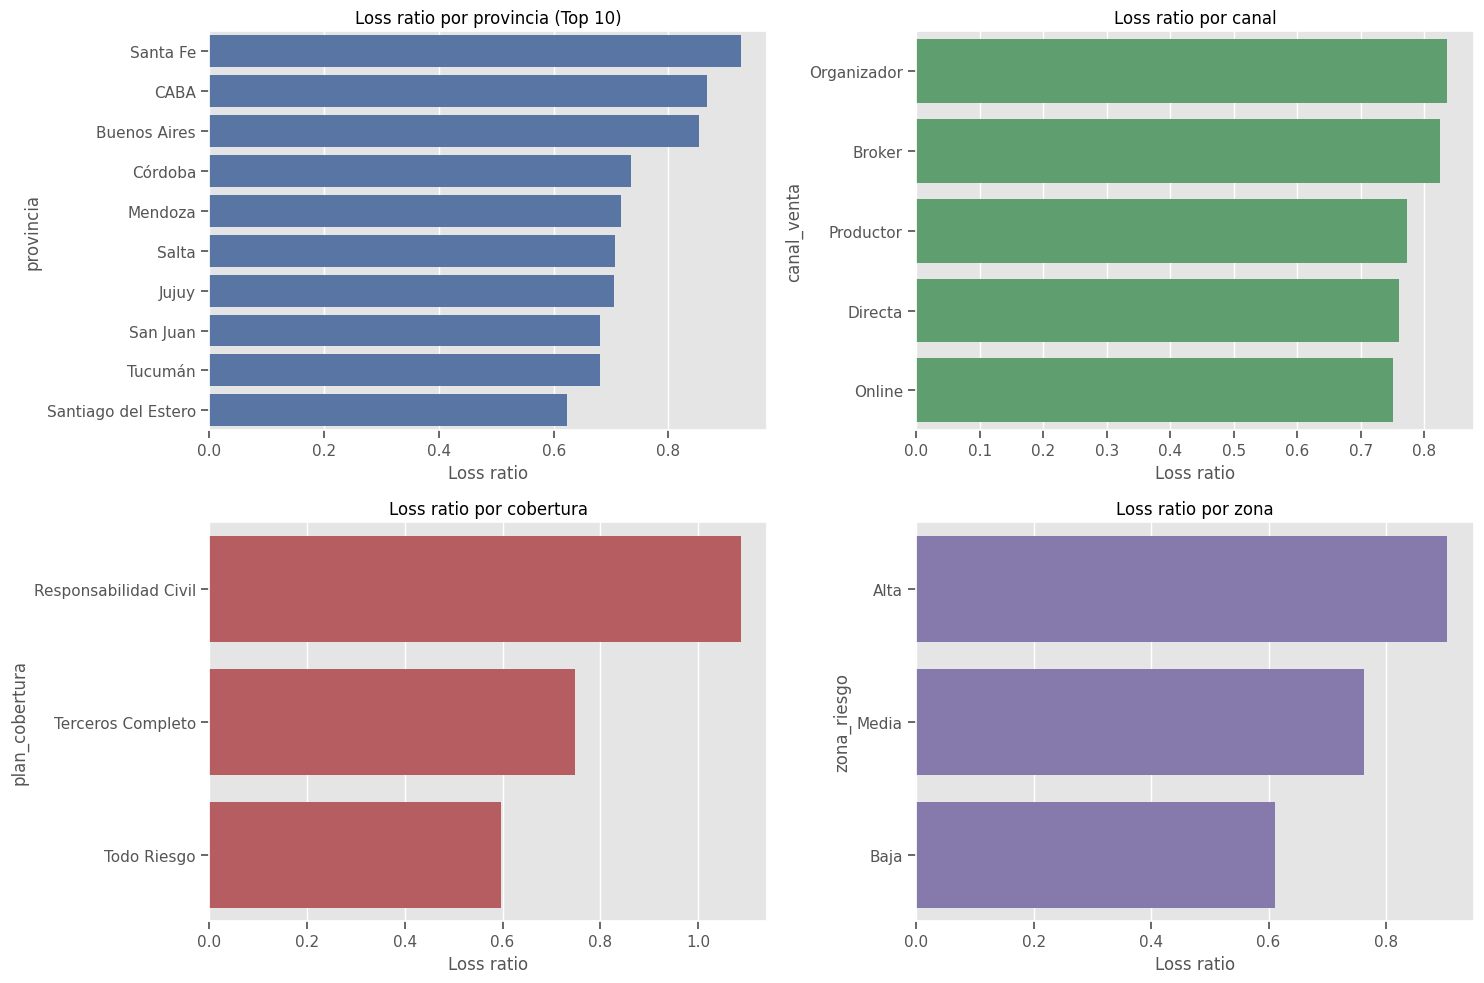

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(15,10))

sns.barplot(data=lr_provincia.head(10), x='loss_ratio', y='provincia', ax=axes[0,0], color='#4c72b0')
axes[0,0].set_title('Loss ratio por provincia (Top 10)')

sns.barplot(data=lr_canal, x='loss_ratio', y='canal_venta', ax=axes[0,1], color='#55a868')
axes[0,1].set_title('Loss ratio por canal')

sns.barplot(data=lr_cobertura, x='loss_ratio', y='plan_cobertura', ax=axes[1,0], color='#c44e52')
axes[1,0].set_title('Loss ratio por cobertura')

sns.barplot(data=lr_zona, x='loss_ratio', y='zona_riesgo', ax=axes[1,1], color='#8172b3')
axes[1,1].set_title('Loss ratio por zona')

for ax in axes.flat:
    ax.set_xlabel('Loss ratio')

plt.tight_layout()
plt.show()


## 4) Analisis Profundo por Grupos

Análisis más detallado que combina **antigüedad del vehículo** (grupos: hasta 2010, 2011-2015, 2016-2020, 2021+) con zona, cobertura y edad. También incluye el **ranking de productores**: los 20 productores con mayor volumen de primas y los 20 con mayor LR (posibles señales de selección adversa o fraude). Los vehículos muy viejos (> 15 años) tienden a tener peor relación costo-reparación; los productores con LR extremo merecen seguimiento.

In [12]:
df_lr['anio_vehiculo_grupo'] = pd.cut(
    df_lr['anio_vehiculo'],
    bins=[2004, 2010, 2015, 2020, 2024],
    labels=['2005-2010', '2011-2015', '2016-2020', '2021-2024']
)

df_lr['antiguedad_vehiculo'] = 2024 - df_lr['anio_vehiculo']
df_lr['antiguedad_vehiculo_grupo'] = pd.cut(
    df_lr['antiguedad_vehiculo'],
    bins=[-1, 2, 7, 15, 50],
    labels=['0-2', '3-7', '8-15', '16+']
)

df_lr['edad_grupo'] = pd.cut(
    df_lr['edad_asegurado'],
    bins=[17, 24, 34, 44, 54, 64, 100],
    labels=['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
)

conteo_siniestros = df_siniestros.groupby('id_poliza').size().rename('cantidad_siniestros')
df_lr = df_lr.merge(conteo_siniestros, on='id_poliza', how='left')
df_lr['cantidad_siniestros'] = df_lr['cantidad_siniestros'].fillna(0).astype(int)
df_lr['tuvo_siniestro'] = df_lr['cantidad_siniestros'] > 0
df_lr['severidad_promedio_poliza'] = np.where(
    df_lr['cantidad_siniestros'] > 0,
    df_lr['siniestros_incurridos'] / df_lr['cantidad_siniestros'],
    np.nan
)


In [13]:
def resumen_segmento(df, grupo):
    base = (
        df.groupby(grupo, as_index=False)
        .agg(
            polizas=('id_poliza', 'count'),
            prima_total=('prima', 'sum'),
            siniestros_total=('siniestros_incurridos', 'sum'),
            frecuencia=('tuvo_siniestro', 'mean'),
            siniestros_por_poliza=('cantidad_siniestros', 'mean'),
            severidad_promedio=('severidad_promedio_poliza', 'mean')
        )
    )
    base['loss_ratio'] = base['siniestros_total'] / base['prima_total']
    return base.sort_values('loss_ratio', ascending=False)

seg_edad = resumen_segmento(df_lr, 'edad_grupo')
seg_productor = resumen_segmento(df_lr, 'codigo_productor')
seg_anio = resumen_segmento(df_lr, 'anio_vehiculo_grupo')
seg_antig = resumen_segmento(df_lr, 'antiguedad_vehiculo_grupo')
seg_tipo = resumen_segmento(df_lr, 'tipo_uso')

display(seg_edad)
display(seg_anio)
display(seg_antig)
display(seg_tipo)


,edad_grupo,polizas,prima_total,siniestros_total,frecuencia,siniestros_por_poliza,severidad_promedio,loss_ratio
2,35-44,11458,"7,014,834,346.49","6,247,869,320.65",0.16,0.18,"3,076,597.52",0.89
3,45-54,10191,"6,142,871,480.76","5,277,822,115.85",0.16,0.17,"2,996,373.08",0.86
1,25-34,14176,"9,403,372,637.02","7,891,014,125.09",0.18,0.20,"2,802,868.35",0.84
4,55-64,5775,"3,671,100,154.99","2,710,262,430.76",0.14,0.15,"3,005,380.78",0.74
0,18-24,6356,"5,397,905,922.76","3,303,367,536.64",0.16,0.18,"2,968,791.03",0.61
5,65+,2044,"1,498,645,550.30","740,313,161.70",0.13,0.14,"2,734,152.82",0.49


,anio_vehiculo_grupo,polizas,prima_total,siniestros_total,frecuencia,siniestros_por_poliza,severidad_promedio,loss_ratio
0,2005-2010,4912,"1,091,368,898.26","2,911,120,510.59",0.17,0.18,"3,240,789.86",2.67
1,2011-2015,8262,"2,738,091,124.22","4,279,169,330.23",0.17,0.18,"2,808,765.29",1.56
2,2016-2020,15165,"8,329,084,974.12","7,842,162,599.28",0.16,0.18,"2,884,214.48",0.94
3,2021-2024,21661,"20,970,185,095.72","11,138,196,250.59",0.16,0.17,"2,968,483.91",0.53


,antiguedad_vehiculo_grupo,polizas,prima_total,siniestros_total,frecuencia,siniestros_por_poliza,severidad_promedio,loss_ratio
3,16+,2826,"627,356,841.64","1,582,267,966.14",0.17,0.19,"2,955,760.95",2.52
2,8-15,12618,"4,251,992,604.01","6,683,776,228.11",0.17,0.18,"2,909,338.83",1.57
1,3-7,17299,"10,590,866,622.80","9,143,433,145.32",0.16,0.18,"2,974,239.39",0.86
0,0-2,17257,"17,658,514,023.87","8,761,171,351.12",0.16,0.17,"2,935,123.84",0.50


,tipo_uso,polizas,prima_total,siniestros_total,frecuencia,siniestros_por_poliza,severidad_promedio,loss_ratio
2,Profesional,2440,"1,584,805,995.38","1,393,628,534.72",0.17,0.19,"2,996,638.79",0.88
0,Comercial,8283,"5,548,182,258.59","4,460,468,598.30",0.17,0.19,"2,931,423.79",0.80
1,Particular,39277,"25,995,741,838.35","20,316,551,557.67",0.16,0.18,"2,942,119.62",0.78


In [14]:
top_productores_vol = seg_productor.sort_values('polizas', ascending=False).head(20)
top_productores_lr = seg_productor[seg_productor['polizas'] >= 40].sort_values('loss_ratio', ascending=False).head(20)

print('Top 20 productores por volumen:')
display(top_productores_vol[['codigo_productor','polizas','frecuencia','loss_ratio']])

print('Top 20 productores por loss ratio (min 40 polizas):')
display(top_productores_lr[['codigo_productor','polizas','frecuencia','loss_ratio','severidad_promedio']])


Top 20 productores por volumen:


,codigo_productor,polizas,frecuencia,loss_ratio
0,PROD-0001,10069,0.16,0.79
1,PROD-0002,4672,0.16,0.84
2,PROD-0003,2938,0.16,0.69
3,PROD-0004,2081,0.17,0.75
4,PROD-0005,1596,0.16,0.77
5,PROD-0006,1338,0.14,0.77
6,PROD-0007,1138,0.16,0.94
7,PROD-0008,980,0.14,0.53
8,PROD-0009,810,0.14,0.59
9,PROD-0010,731,0.16,0.82


Top 20 productores por loss ratio (min 40 polizas):


,codigo_productor,polizas,frecuencia,loss_ratio,severidad_promedio
90,PROD-0091,61,0.21,2.87,"9,323,516.20"
157,PROD-0158,44,0.20,2.38,"7,671,615.05"
133,PROD-0134,43,0.12,2.13,"12,266,310.96"
74,PROD-0075,87,0.24,1.87,"5,038,765.35"
107,PROD-0108,41,0.22,1.83,"3,590,065.15"
36,PROD-0037,171,0.18,1.63,"5,575,498.86"
39,PROD-0040,154,0.18,1.57,"5,530,961.13"
89,PROD-0090,61,0.23,1.50,"4,327,373.17"
67,PROD-0068,100,0.22,1.48,"3,491,840.97"
46,PROD-0047,124,0.23,1.44,"3,190,974.76"


## 5) Heatmaps adicionales por edad_grupo

Los **heatmaps** permiten visualizar el LR en la **intersección de dos variables** simultáneamente. Se generan cuatro cruces: edad × canal de venta, zona × cobertura, provincia × cobertura (top 8 provincias), y zona × tipo de daño. Las celdas más oscuras/intensas indican segmentos de mayor siniestralidad. Esta vista es útil para identificar combinaciones de riesgo que no serían visibles analizando una variable a la vez.

In [15]:
def matriz_metricas(df, filas, cols, metrica='loss_ratio'):
    g = (
        df.groupby([filas, cols])
        .apply(lambda x: (x['siniestros_incurridos'].sum() / x['prima'].sum()) if metrica == 'loss_ratio' else x['tuvo_siniestro'].mean())
        .rename(metrica)
        .reset_index()
    )
    return g.pivot(index=filas, columns=cols, values=metrica)

hm_edad_canal_lr = matriz_metricas(df_lr, 'edad_grupo', 'canal_venta', metrica='loss_ratio')
hm_edad_uso_lr = matriz_metricas(df_lr, 'edad_grupo', 'tipo_uso', metrica='loss_ratio')
hm_edad_zona_freq = matriz_metricas(df_lr, 'edad_grupo', 'zona_riesgo', metrica='frecuencia')
hm_edad_antig_lr = matriz_metricas(df_lr, 'edad_grupo', 'antiguedad_vehiculo_grupo', metrica='loss_ratio')

display(hm_edad_canal_lr)
display(hm_edad_uso_lr)
display(hm_edad_zona_freq)
display(hm_edad_antig_lr)


canal_venta,Broker,Directa,Online,Organizador,Productor
edad_grupo,,,,,
18-24,0.65,0.53,0.63,0.59,0.62
25-34,0.89,0.78,0.60,0.93,0.83
35-44,0.99,0.88,1.01,0.92,0.84
45-54,0.80,0.76,0.90,0.74,0.93
55-64,0.80,0.88,0.64,0.96,0.63
65+,0.43,0.67,0.69,0.75,0.40


tipo_uso,Comercial,Particular,Profesional
edad_grupo,,,
18-24,1.03,0.50,1.02
25-34,0.79,0.86,0.75
35-44,0.77,0.91,0.99
45-54,0.80,0.86,1.04
55-64,0.63,0.76,0.74
65+,0.66,0.46,0.43


zona_riesgo,Alta,Baja,Media
edad_grupo,,,
18-24,0.19,0.14,0.14
25-34,0.21,0.15,0.17
35-44,0.20,0.11,0.18
45-54,0.20,0.11,0.16
55-64,0.14,0.13,0.14
65+,0.12,0.14,0.12


antiguedad_vehiculo_grupo,0-2,3-7,8-15,16+
edad_grupo,,,,
18-24,0.38,0.70,1.11,2.38
25-34,0.55,0.95,1.55,2.42
35-44,0.56,0.92,1.85,3.19
45-54,0.53,0.96,1.69,2.59
55-64,0.43,0.75,1.82,2.08
65+,0.30,0.56,1.03,1.08


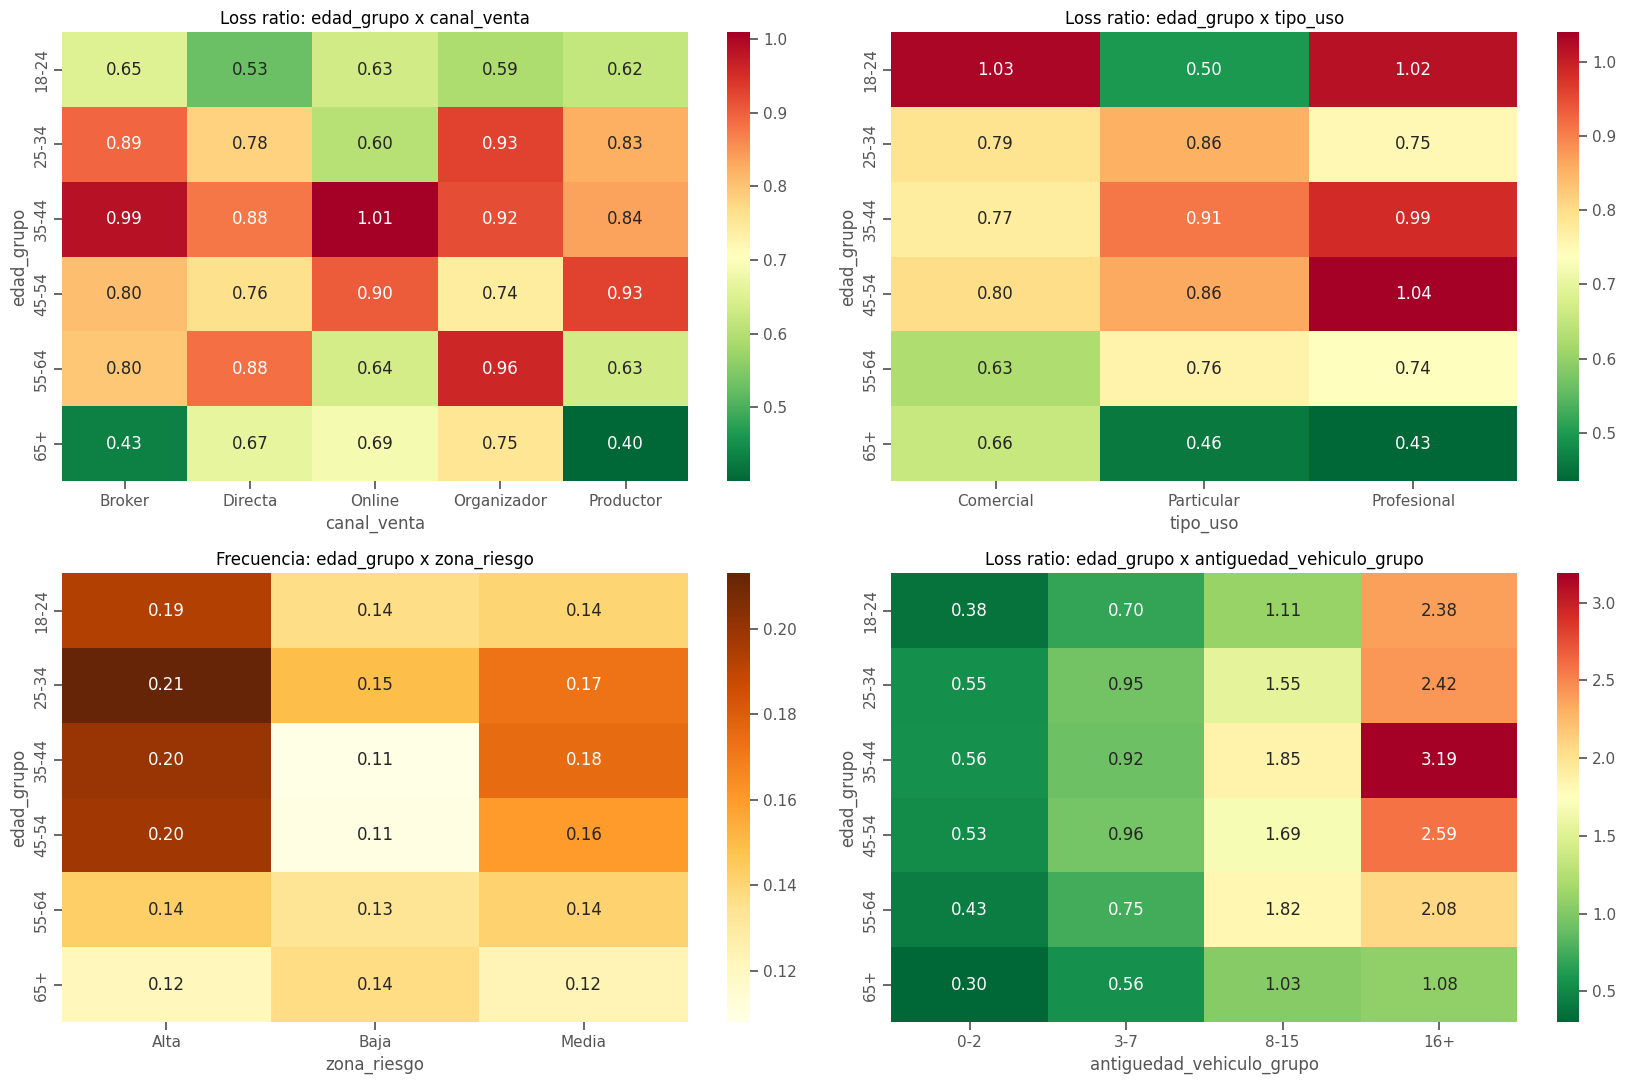

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(17, 11))

sns.heatmap(hm_edad_canal_lr, annot=True, fmt='.2f', cmap='RdYlGn_r', ax=axes[0,0])
axes[0,0].set_title('Loss ratio: edad_grupo x canal_venta')

sns.heatmap(hm_edad_uso_lr, annot=True, fmt='.2f', cmap='RdYlGn_r', ax=axes[0,1])
axes[0,1].set_title('Loss ratio: edad_grupo x tipo_uso')

sns.heatmap(hm_edad_zona_freq, annot=True, fmt='.2f', cmap='YlOrBr', ax=axes[1,0])
axes[1,0].set_title('Frecuencia: edad_grupo x zona_riesgo')

sns.heatmap(hm_edad_antig_lr, annot=True, fmt='.2f', cmap='RdYlGn_r', ax=axes[1,1])
axes[1,1].set_title('Loss ratio: edad_grupo x antiguedad_vehiculo_grupo')

plt.tight_layout()
plt.show()


## 6) Segmentacion multivariable (provincia + cobertura + edad_grupo)

Segmentación en **tres dimensiones simultáneas**: provincia × plan de cobertura × grupo de edad. Se filtran los segmentos con al menos 30 pólizas para garantizar significancia estadística, y se ordenan por LR descendente. Luego se profundiza en la provincia de mayor volumen, mostrando los 10 sub-segmentos más rentables y los 10 peores. Este análisis es la base para decisiones de re-tarificación o restricción de suscripción por segmento.

In [17]:
seg_multi = (
    df_lr.groupby(['provincia', 'plan_cobertura', 'edad_grupo'], as_index=False)
    .agg(
        polizas=('id_poliza', 'count'),
        prima_total=('prima', 'sum'),
        siniestros_total=('siniestros_incurridos', 'sum'),
        frecuencia=('tuvo_siniestro', 'mean')
    )
)
seg_multi['loss_ratio'] = seg_multi['siniestros_total'] / seg_multi['prima_total']
seg_multi_filtrado = seg_multi[seg_multi['polizas'] >= 60].copy()

top_celdas = seg_multi_filtrado.sort_values('loss_ratio', ascending=False).head(25)
display(top_celdas)
print('Celdas analizadas (min 60 polizas):', len(seg_multi_filtrado))


,provincia,plan_cobertura,edad_grupo,polizas,prima_total,siniestros_total,frecuencia,loss_ratio
271,San Juan,Responsabilidad Civil,25-34,107,"34,199,676.84","87,032,407.33",0.15,2.54
308,Santa Fe,Responsabilidad Civil,35-44,349,"150,094,310.29","335,810,530.70",0.19,2.24
345,Tucumán,Responsabilidad Civil,45-54,145,"45,676,825.68","92,173,693.61",0.08,2.02
259,Salta,Terceros Completo,25-34,151,"76,188,765.80","131,261,485.70",0.23,1.72
307,Santa Fe,Responsabilidad Civil,25-34,494,"227,096,197.51","369,449,698.20",0.18,1.63
315,Santa Fe,Terceros Completo,45-54,297,"192,253,555.90","301,666,690.44",0.21,1.57
346,Tucumán,Responsabilidad Civil,55-64,83,"27,697,952.04","41,092,053.40",0.18,1.48
188,Mendoza,Terceros Completo,35-44,202,"127,599,286.05","186,214,494.82",0.18,1.46
216,Neuquén,Responsabilidad Civil,18-24,78,"27,161,909.01","38,902,846.28",0.22,1.43
325,Santiago del Estero,Responsabilidad Civil,25-34,127,"38,252,158.01","54,299,870.37",0.13,1.42


Celdas analizadas (min 60 polizas): 188


plan_cobertura,Responsabilidad Civil,Terceros Completo,Todo Riesgo
edad_grupo,,,
18-24,1.13,0.57,0.41
25-34,1.31,0.81,0.74
35-44,1.40,0.77,0.89
45-54,1.11,0.89,0.64
55-64,0.80,0.83,0.85
65+,0.67,0.35,0.49


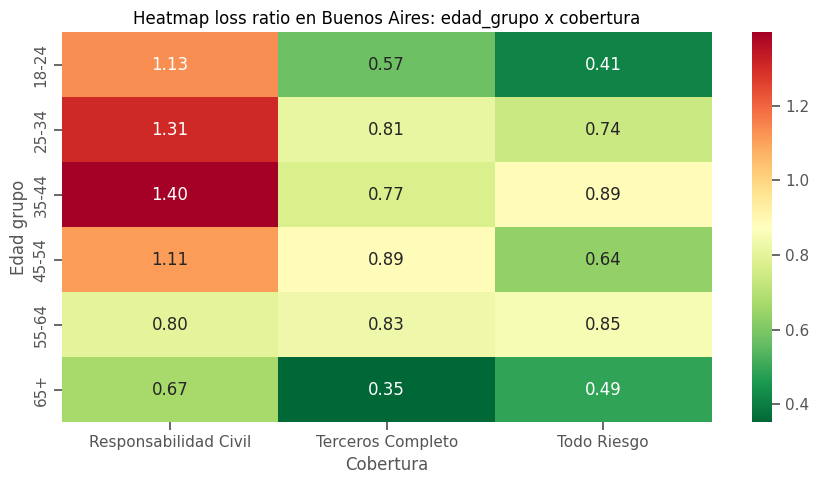

In [18]:
prov_obj = 'Buenos Aires' if (seg_multi_filtrado['provincia'] == 'Buenos Aires').any() else seg_multi_filtrado['provincia'].mode().iloc[0]
base_prov = seg_multi_filtrado[seg_multi_filtrado['provincia'] == prov_obj].copy()

pivot_multi = base_prov.pivot_table(
    index='edad_grupo',
    columns='plan_cobertura',
    values='loss_ratio',
    aggfunc='mean'
)
display(pivot_multi)

plt.figure(figsize=(9, 5))
sns.heatmap(pivot_multi, annot=True, fmt='.2f', cmap='RdYlGn_r')
plt.title(f'Heatmap loss ratio en {prov_obj}: edad_grupo x cobertura')
plt.xlabel('Cobertura')
plt.ylabel('Edad grupo')
plt.tight_layout()
plt.show()


### Ideas para profundizar aun mas
- Ranking de outliers con `loss_ratio_poliza` extremo y validacion de severidad RC.
- Evolucion temporal mensual de frecuencia y severidad para detectar estacionalidad.

## 7) Nuevas variables: distribuciones base

Esta sección presenta las distribuciones de las **nuevas columnas** incorporadas en esta versión del dataset. Se muestran: el ramo regulatorio (`ramo`: "Automotor" vs "Motovehiculos"), el tipo de vehículo, la categoría de cobertura (Solo RC / RC+Casco Básico / RC+Casco Total), la bandera de flota, la asignación a organizador, y la categoría del siniestro (Casco / RC / Mixto). Sirve como verificación de que las proporciones del dataset coinciden con los pesos configurados.

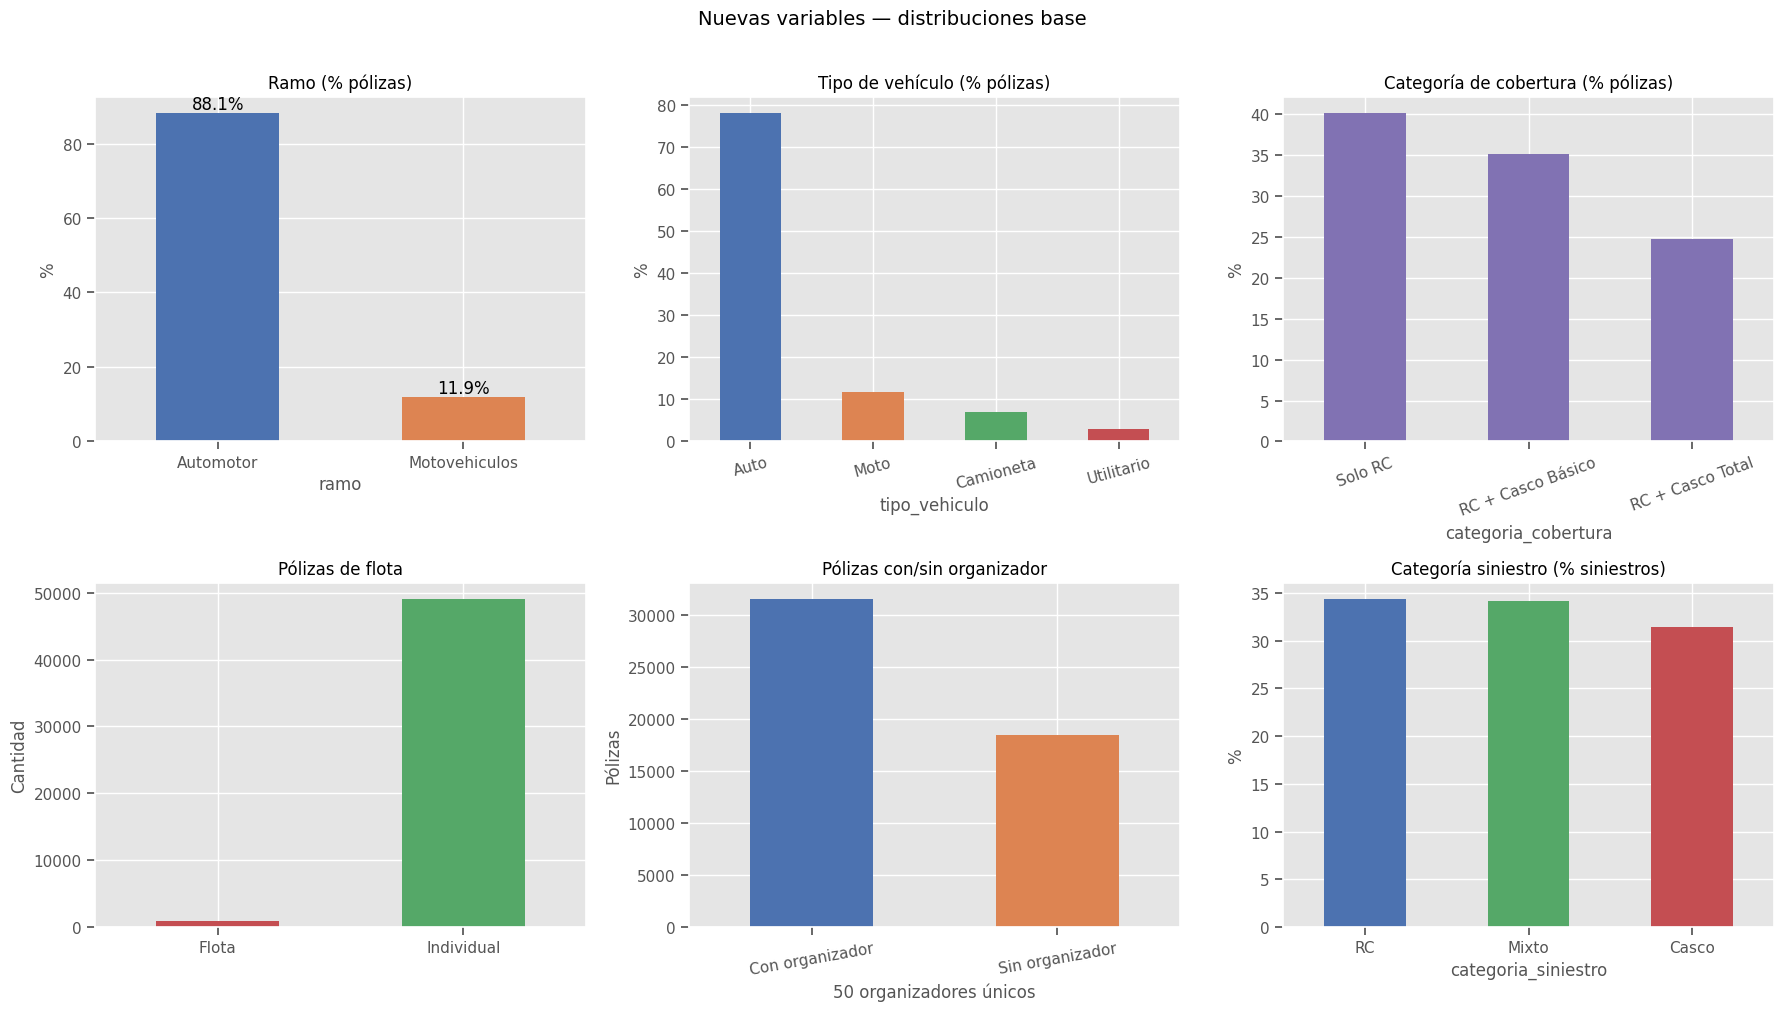

In [19]:

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Ramo
if 'ramo' in df_polizas.columns:
    (df_polizas['ramo'].value_counts(normalize=True).mul(100)
     .plot(kind='bar', ax=axes[0, 0], color=['#4c72b0', '#dd8452'],
           title='Ramo (% pólizas)'))
    axes[0, 0].set_ylabel('%'); axes[0, 0].tick_params(axis='x', rotation=0)
    for p in axes[0, 0].patches:
        axes[0, 0].annotate(f'{p.get_height():.1f}%',
                            (p.get_x() + p.get_width()/2, p.get_height()),
                            ha='center', va='bottom')

# tipo_vehiculo
if 'tipo_vehiculo' in df_polizas.columns:
    (df_polizas['tipo_vehiculo'].value_counts(normalize=True).mul(100)
     .sort_values(ascending=False)
     .plot(kind='bar', ax=axes[0, 1], color=['#4c72b0','#dd8452','#55a868','#c44e52'],
           title='Tipo de vehículo (% pólizas)'))
    axes[0, 1].set_ylabel('%'); axes[0, 1].tick_params(axis='x', rotation=15)

# categoria_cobertura
if 'categoria_cobertura' in df_polizas.columns:
    (df_polizas['categoria_cobertura'].value_counts(normalize=True).mul(100)
     .sort_values(ascending=False)
     .plot(kind='bar', ax=axes[0, 2], color='#8172b3',
           title='Categoría de cobertura (% pólizas)'))
    axes[0, 2].set_ylabel('%'); axes[0, 2].tick_params(axis='x', rotation=20)

# es_flota
if 'es_flota' in df_polizas.columns:
    pd.Series({
        'Flota': df_polizas['es_flota'].sum(),
        'Individual': (~df_polizas['es_flota']).sum()
    }).plot(kind='bar', ax=axes[1, 0], color=['#c44e52', '#55a868'],
            title='Pólizas de flota')
    axes[1, 0].set_ylabel('Cantidad'); axes[1, 0].tick_params(axis='x', rotation=0)

# Organizadores: fill rate
if 'codigo_organizador' in df_polizas.columns:
    pd.Series({
        'Con organizador': df_polizas['codigo_organizador'].notna().sum(),
        'Sin organizador': df_polizas['codigo_organizador'].isna().sum()
    }).plot(kind='bar', ax=axes[1, 1], color=['#4c72b0', '#dd8452'],
            title='Pólizas con/sin organizador')
    axes[1, 1].set_ylabel('Pólizas'); axes[1, 1].tick_params(axis='x', rotation=10)
    n_orgs = df_polizas['codigo_organizador'].nunique()
    axes[1, 1].set_xlabel(f'{n_orgs} organizadores únicos')

# categoria_siniestro
if 'categoria_siniestro' in df_siniestros.columns:
    (df_siniestros['categoria_siniestro'].value_counts(normalize=True).mul(100)
     .sort_values(ascending=False)
     .plot(kind='bar', ax=axes[1, 2], color=['#4c72b0','#55a868','#c44e52'],
           title='Categoría siniestro (% siniestros)'))
    axes[1, 2].set_ylabel('%'); axes[1, 2].tick_params(axis='x', rotation=0)

plt.suptitle('Nuevas variables — distribuciones base', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## 8) Análisis por tipo de vehículo

Comparación del **comportamiento siniestral por tipo de vehículo** (Auto, Moto, Camioneta, Utilitario). Se analiza el LR, la frecuencia de siniestros y la severidad media por tipo. Las motos tienen una frecuencia inherentemente mayor (lambda ×1.7) y distinta distribución de tipos de daño (más choques y daños a terceros, menos granizo). Las camionetas tienen menor frecuencia (lambda ×0.85). Los gráficos incluyen la distribución de tipos de daño por vehículo y boxplots de montos reclamados.

Resumen por tipo de vehículo:


,tipo_vehiculo,polizas,frecuencia,severidad_promedio,loss_ratio
2,Moto,5926,0.25,"933,748.50",1.99
3,Utilitario,1518,0.16,"3,752,755.31",1.08
0,Auto,39009,0.15,"3,379,512.67",0.79
1,Camioneta,3547,0.12,"3,362,157.47",0.45


/var/folders/hx/cw6hcqms3rd1w68c2xv16pdc0000gn/T/ipykernel_18786/3040768098.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lr_tv, x='tipo_vehiculo', y='loss_ratio', ax=axes[0, 0], palette='muted')


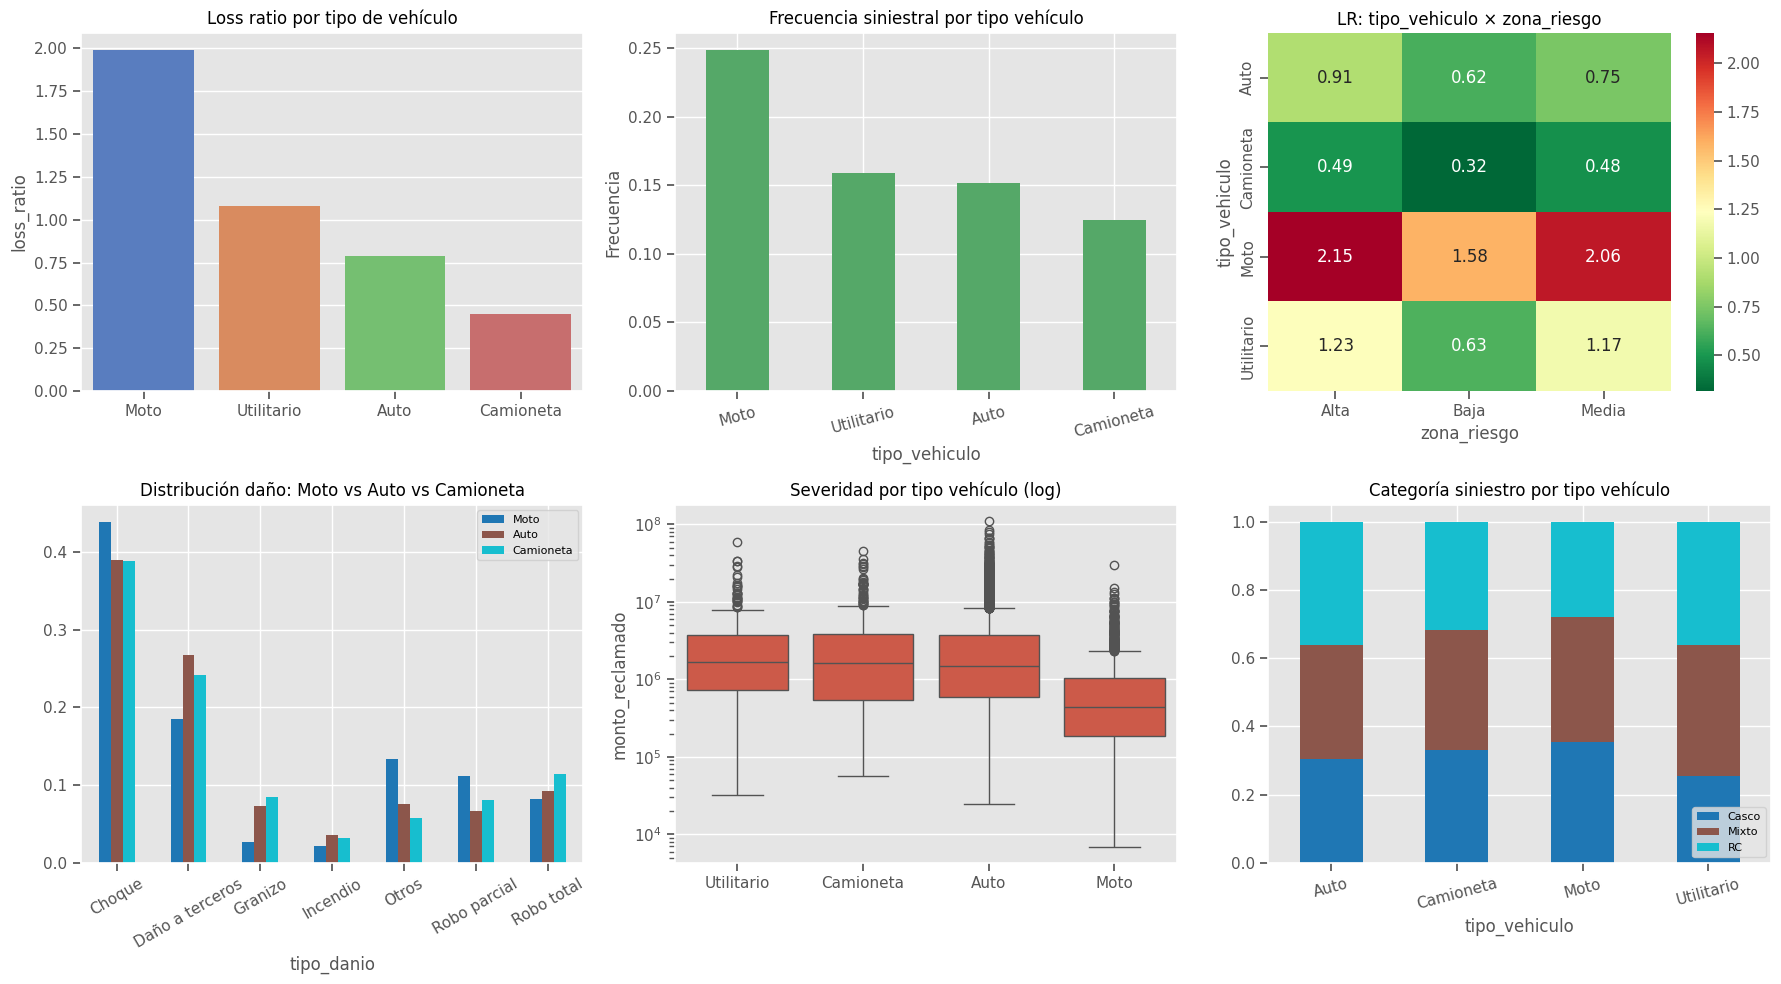

In [20]:

if 'tipo_vehiculo' not in df_lr.columns:
    df_lr = df_lr.merge(df_polizas[['id_poliza', 'tipo_vehiculo']], on='id_poliza', how='left')

# Siniestros enriquecidos con tipo_vehiculo
df_sin_tv = df_siniestros.merge(
    df_polizas[['id_poliza', 'tipo_vehiculo']], on='id_poliza', how='left')

lr_tv = resumen_segmento(df_lr, 'tipo_vehiculo')
print('Resumen por tipo de vehículo:')
display(lr_tv[['tipo_vehiculo', 'polizas', 'frecuencia', 'severidad_promedio', 'loss_ratio']])

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# LR por tipo_vehiculo
sns.barplot(data=lr_tv, x='tipo_vehiculo', y='loss_ratio', ax=axes[0, 0], palette='muted')
axes[0, 0].set_title('Loss ratio por tipo de vehículo'); axes[0, 0].set_xlabel('')

# Frecuencia por tipo_vehiculo
freq_tv = df_lr.groupby('tipo_vehiculo')['tuvo_siniestro'].mean().sort_values(ascending=False)
freq_tv.plot(kind='bar', ax=axes[0, 1], color='#55a868',
             title='Frecuencia siniestral por tipo vehículo')
axes[0, 1].set_ylabel('Frecuencia'); axes[0, 1].tick_params(axis='x', rotation=15)

# Heatmap: tipo_vehiculo × zona_riesgo → LR
hm_tv_zona = (df_lr.groupby(['tipo_vehiculo', 'zona_riesgo'])
              .apply(lambda x: x['siniestros_incurridos'].sum() / x['prima'].sum())
              .unstack())
sns.heatmap(hm_tv_zona, annot=True, fmt='.2f', cmap='RdYlGn_r', ax=axes[0, 2])
axes[0, 2].set_title('LR: tipo_vehiculo × zona_riesgo')

# Distribución de daño: Moto vs Auto
danio_tv = df_sin_tv.groupby(['tipo_vehiculo', 'tipo_danio']).size().unstack(fill_value=0)
danio_tv_pct = danio_tv.div(danio_tv.sum(axis=1), axis=0)
tvs_disponibles = [tv for tv in ['Moto', 'Auto', 'Camioneta'] if tv in danio_tv_pct.index]
danio_tv_pct.loc[tvs_disponibles].T.plot(kind='bar', ax=axes[1, 0], colormap='tab10')
axes[1, 0].set_title('Distribución daño: Moto vs Auto vs Camioneta')
axes[1, 0].tick_params(axis='x', rotation=30); axes[1, 0].legend(loc='upper right', fontsize=8)

# Boxplot severidad por tipo_vehiculo
orden_tv = (df_sin_tv.groupby('tipo_vehiculo')['monto_reclamado']
            .median().sort_values(ascending=False).index)
sns.boxplot(data=df_sin_tv.dropna(subset=['tipo_vehiculo']),
            x='tipo_vehiculo', y='monto_reclamado', order=orden_tv, ax=axes[1, 1])
axes[1, 1].set_yscale('log'); axes[1, 1].set_title('Severidad por tipo vehículo (log)')
axes[1, 1].set_xlabel('')

# categoria_siniestro por tipo_vehiculo (stacked %)
if 'categoria_siniestro' in df_sin_tv.columns:
    cat_tv = df_sin_tv.groupby(['tipo_vehiculo', 'categoria_siniestro']).size().unstack(fill_value=0)
    cat_tv_pct = cat_tv.div(cat_tv.sum(axis=1), axis=0)
    cat_tv_pct.plot(kind='bar', stacked=True, ax=axes[1, 2], colormap='tab10',
                    title='Categoría siniestro por tipo vehículo')
    axes[1, 2].tick_params(axis='x', rotation=15)
    axes[1, 2].legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()


## 9) Organizadores y pólizas de flota

Análisis de la **red de distribución**: los organizadores son grupos de productores (~50 en total) a los que pertenece el 80% de los productores. Se muestran los top 20 organizadores por volumen de primas y su LR respectivo, permitiendo identificar organizadores con peor resultado técnico. También se compara el comportamiento de las **pólizas de flota** (2% del total, forzadas a uso Comercial) frente a las pólizas individuales en términos de LR y monto reclamado medio.

/var/folders/hx/cw6hcqms3rd1w68c2xv16pdc0000gn/T/ipykernel_18786/867874937.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lr_tiene, x='grupo', y='loss_ratio', ax=axes[1, 0],


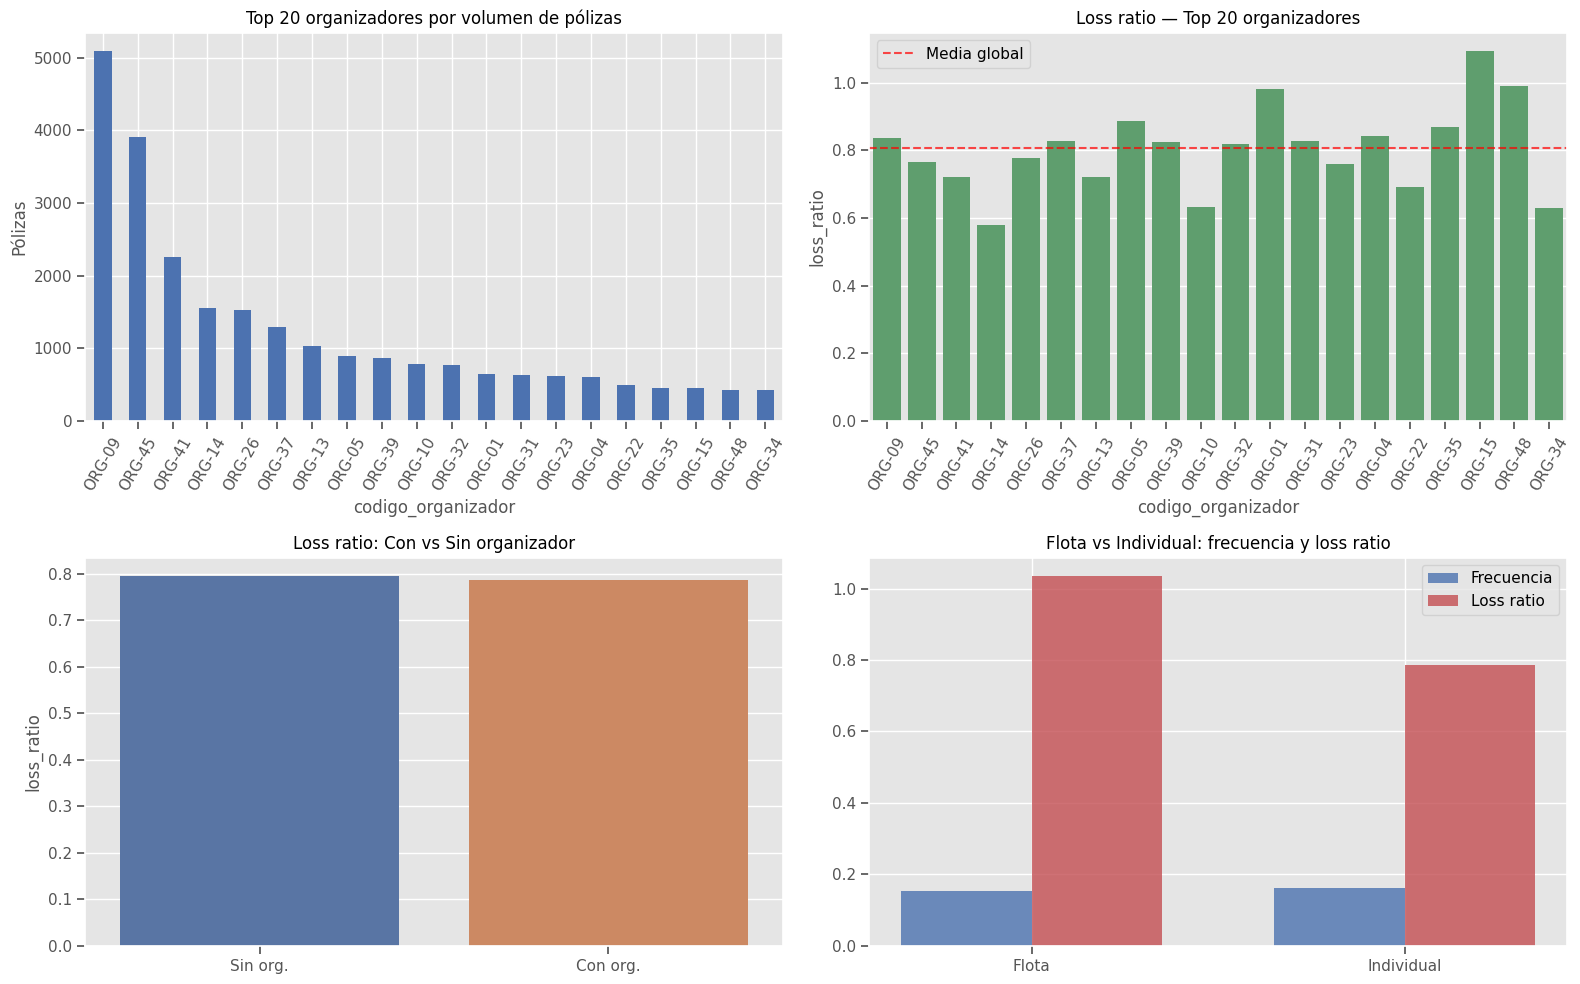

In [21]:

# Enrich df_lr with organizador and flota columns (defensive)
for _col in ['codigo_organizador', 'es_flota']:
    if _col not in df_lr.columns and _col in df_polizas.columns:
        df_lr = df_lr.merge(df_polizas[['id_poliza', _col]], on='id_poliza', how='left')

df_lr['tiene_organizador'] = df_lr['codigo_organizador'].notna() if 'codigo_organizador' in df_lr.columns else False

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ── Top 20 organizadores por volumen ───────────────────────────────────────
if 'codigo_organizador' in df_lr.columns:
    lr_org = resumen_loss_ratio(df_lr[df_lr['tiene_organizador']], 'codigo_organizador')
    lr_org_top20 = lr_org.sort_values('polizas', ascending=False).head(20)
    lr_org_top20.set_index('codigo_organizador')['polizas'].plot(
        kind='bar', ax=axes[0, 0], color='#4c72b0',
        title='Top 20 organizadores por volumen de pólizas')
    axes[0, 0].set_ylabel('Pólizas'); axes[0, 0].tick_params(axis='x', rotation=60)

    # LR por organizador (top 20 por volumen)
    sns.barplot(data=lr_org_top20, x='codigo_organizador', y='loss_ratio',
                order=lr_org_top20['codigo_organizador'].tolist(), ax=axes[0, 1],
                color='#55a868')
    axes[0, 1].set_title('Loss ratio — Top 20 organizadores')
    axes[0, 1].tick_params(axis='x', rotation=60)
    axes[0, 1].axhline(y=lr_org['loss_ratio'].mean(), color='red',
                       linestyle='--', alpha=0.7, label='Media global')
    axes[0, 1].legend()

    # Con vs sin organizador
    lr_tiene = resumen_loss_ratio(df_lr, 'tiene_organizador')
    lr_tiene['grupo'] = lr_tiene['tiene_organizador'].map({True: 'Con org.', False: 'Sin org.'})
    sns.barplot(data=lr_tiene, x='grupo', y='loss_ratio', ax=axes[1, 0],
                palette=['#4c72b0', '#dd8452'])
    axes[1, 0].set_title('Loss ratio: Con vs Sin organizador')
    axes[1, 0].set_xlabel('')

# ── Flota vs individual ────────────────────────────────────────────────────
if 'es_flota' in df_lr.columns:
    lr_flota = resumen_loss_ratio(df_lr, 'es_flota')
    freq_flota = df_lr.groupby('es_flota')['tuvo_siniestro'].mean()
    lr_flota['frecuencia'] = lr_flota['es_flota'].map(freq_flota.to_dict())
    lr_flota['grupo'] = lr_flota['es_flota'].map({True: 'Flota', False: 'Individual'})

    x = np.arange(2)
    width = 0.35
    axes[1, 1].bar(x - width/2, lr_flota.set_index('grupo')['frecuencia'],
                   width, label='Frecuencia', color='#4c72b0', alpha=0.8)
    axes[1, 1].bar(x + width/2, lr_flota.set_index('grupo')['loss_ratio'],
                   width, label='Loss ratio', color='#c44e52', alpha=0.8)
    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels(['Flota', 'Individual'])
    axes[1, 1].set_title('Flota vs Individual: frecuencia y loss ratio')
    axes[1, 1].legend()

plt.tight_layout()
plt.show()


## 10) Categorías de cobertura y siniestro

La **categoría de cobertura** clasifica cada póliza en tres niveles: "Solo RC" (solo responsabilidad civil ante terceros), "RC + Casco Básico" (agrega robo y daños parciales al vehículo propio) y "RC + Casco Total" (cobertura completa incluyendo todo riesgo). Se espera que el loss ratio sea más alto en "Solo RC" porque la prima es baja pero los siniestros de terceros pueden ser costosos.

La **categoría de siniestro** clasifica cada reclamo según qué cobertura lo absorbe: "Casco" (daño al vehículo propio), "RC" (daño a terceros) o "Mixto" (ambos). Analizar la distribución por tipo_vehiculo y tipo_danio permite entender el perfil de riesgo de cada segmento.

Loss ratio por categoría de cobertura:


,categoria_cobertura,polizas,prima_total,siniestros_total,loss_ratio
2,Solo RC,20075,"9,321,374,345.44","10,129,870,185.65",1.09
0,RC + Casco Básico,17560,"12,234,128,813.47","9,144,576,736.30",0.75
1,RC + Casco Total,12365,"11,573,226,933.41","6,896,201,768.74",0.60


/var/folders/hx/cw6hcqms3rd1w68c2xv16pdc0000gn/T/ipykernel_18786/3481036917.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lr_cat_cob, x='categoria_cobertura', y='loss_ratio',


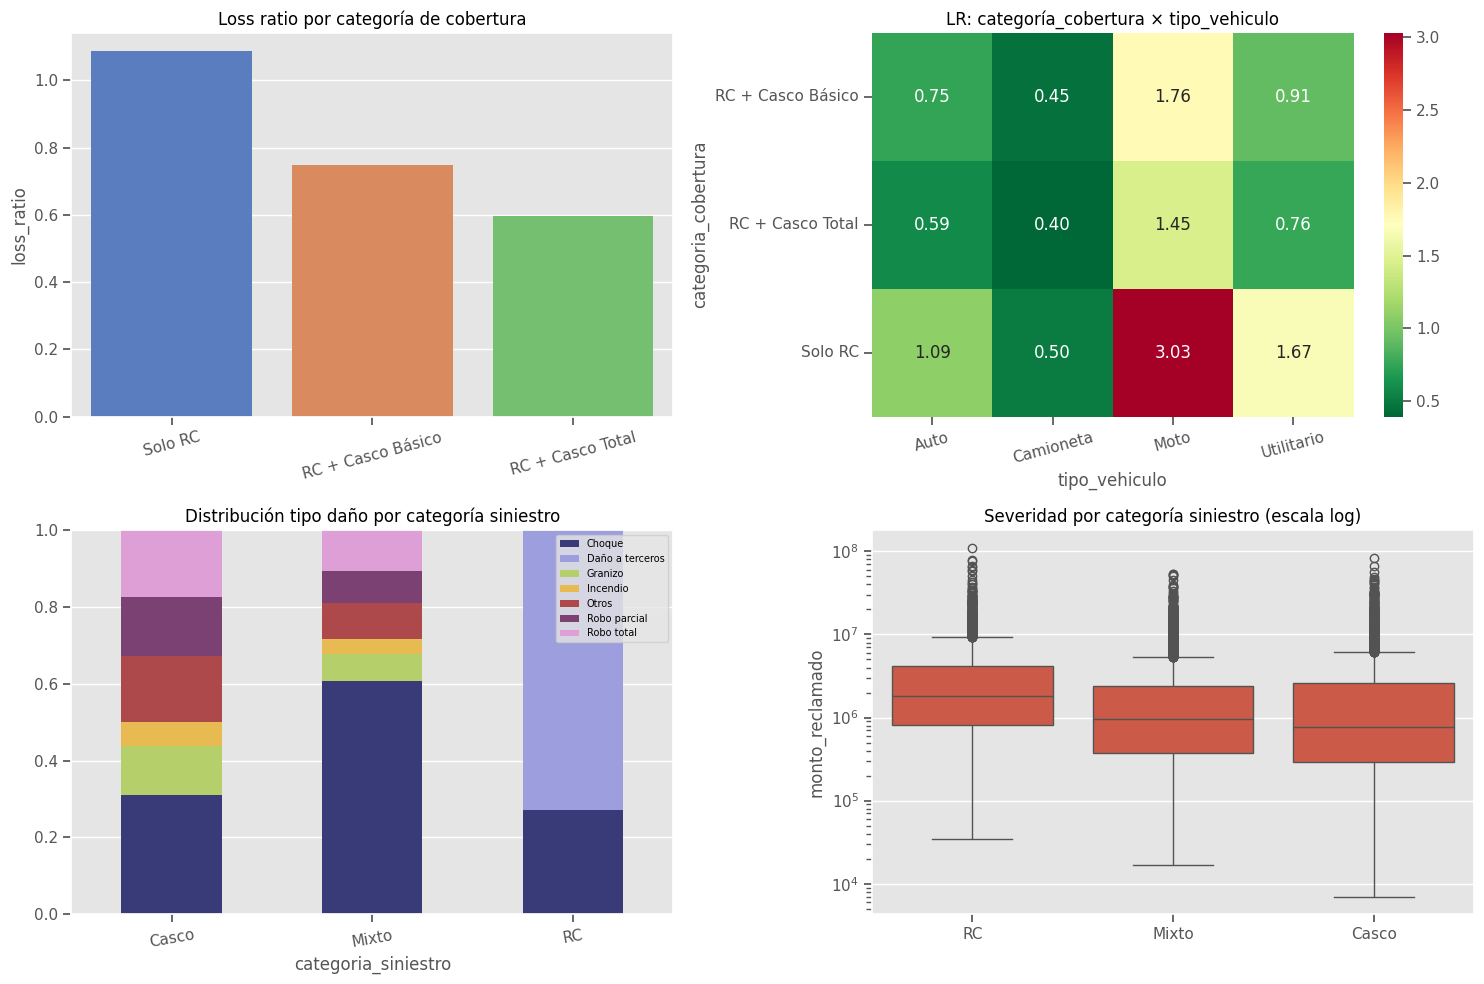

In [22]:

# ── Categoría de cobertura × tipo_vehiculo ──────────────────────────────────
if 'categoria_cobertura' not in df_lr.columns:
    df_lr = df_lr.merge(df_polizas[['id_poliza', 'categoria_cobertura']], on='id_poliza', how='left')

lr_cat_cob = resumen_loss_ratio(df_lr, 'categoria_cobertura')
print('Loss ratio por categoría de cobertura:')
display(lr_cat_cob)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# LR by categoria_cobertura
sns.barplot(data=lr_cat_cob, x='categoria_cobertura', y='loss_ratio',
            ax=axes[0, 0], palette='muted')
axes[0, 0].set_title('Loss ratio por categoría de cobertura')
axes[0, 0].set_xlabel(''); axes[0, 0].tick_params(axis='x', rotation=15)

# Heatmap: categoria_cobertura × tipo_vehiculo → LR
if 'tipo_vehiculo' in df_lr.columns:
    hm_cob_tv = (df_lr.groupby(['categoria_cobertura', 'tipo_vehiculo'])
                 .apply(lambda x: x['siniestros_incurridos'].sum() / x['prima'].sum())
                 .unstack())
    sns.heatmap(hm_cob_tv, annot=True, fmt='.2f', cmap='RdYlGn_r', ax=axes[0, 1])
    axes[0, 1].set_title('LR: categoría_cobertura × tipo_vehiculo')
    axes[0, 1].tick_params(axis='x', rotation=15)
else:
    axes[0, 1].set_visible(False)

# categoria_siniestro × tipo_danio
if 'categoria_siniestro' in df_siniestros.columns:
    cat_danio = (df_siniestros.groupby(['categoria_siniestro', 'tipo_danio']).size()
                 .unstack(fill_value=0))
    cat_danio_pct = cat_danio.div(cat_danio.sum(axis=1), axis=0)
    cat_danio_pct.plot(kind='bar', stacked=True, ax=axes[1, 0], colormap='tab20b')
    axes[1, 0].set_title('Distribución tipo daño por categoría siniestro')
    axes[1, 0].tick_params(axis='x', rotation=10)
    axes[1, 0].legend(fontsize=7, loc='upper right')

# Severidad por categoria_siniestro
if 'categoria_siniestro' in df_siniestros.columns:
    orden_cat = (df_siniestros.groupby('categoria_siniestro')['monto_reclamado']
                 .median().sort_values(ascending=False).index)
    sns.boxplot(data=df_siniestros, x='categoria_siniestro', y='monto_reclamado',
                order=orden_cat, ax=axes[1, 1])
    axes[1, 1].set_yscale('log')
    axes[1, 1].set_title('Severidad por categoría siniestro (escala log)')
    axes[1, 1].set_xlabel('')

plt.tight_layout()
plt.show()


## 11) Estacionalidad, edad bimodal y outliers

Los gráficos de **estacionalidad** muestran si la frecuencia de siniestros varía según el mes del año para cada tipo de daño. Se espera concentración de Granizo en primavera-verano argentino (Oct–Mar), Choques con leve pico invernal (Jul–Ago por niebla y escarcha) y Robos con pico en diciembre-febrero (vacaciones). El heatmap de mes × tipo_danio confirma visualmente estos patrones.

La **distribución de edad bimodal** refleja dos perfiles de asegurado: conductores jóvenes (~27 años) y maduros (~46 años). El gráfico de densidad por tipo de vehículo permite ver si las motos atraen más a conductores jóvenes.

El histograma de **suma asegurada** muestra la distribución general y los outliers por encima de 45M ARS (vehículos premium o flotas). El gráfico logarítmico del monto reclamado evidencia la cola pesada: la mayoría de siniestros son pequeños, pero existe un ~1% catastrófico con montos 2.5–5× superiores (señal de fraude o accidentes graves).

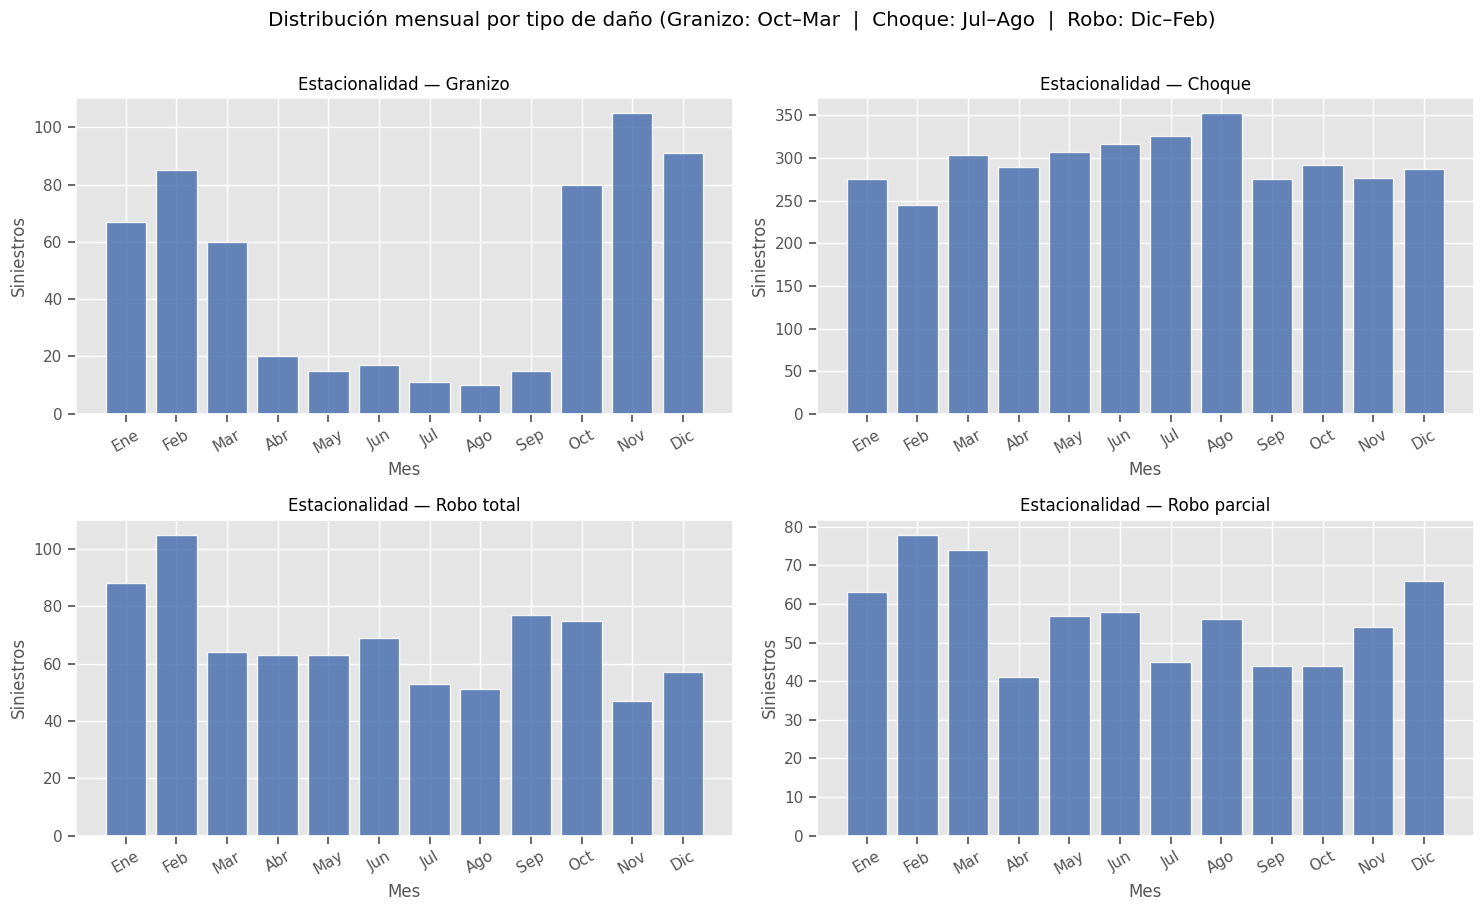

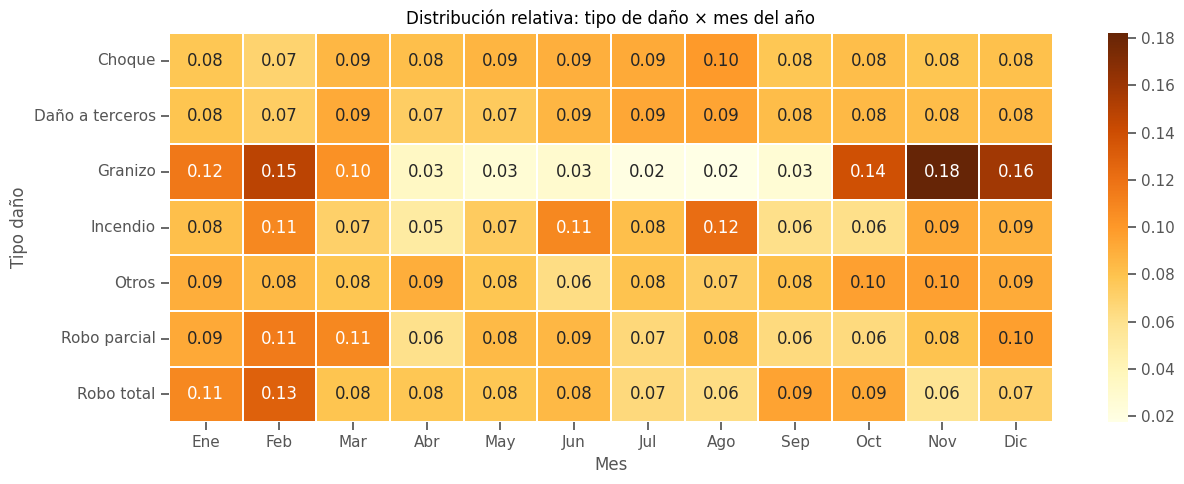

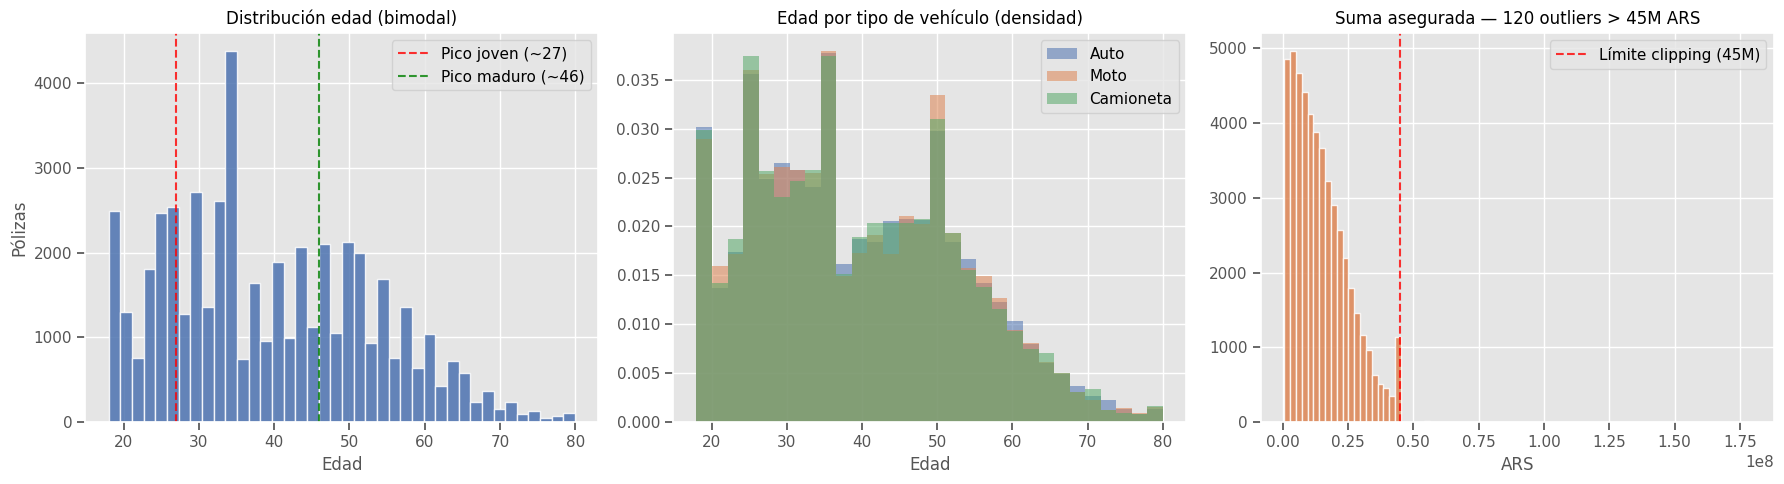

P99 monto reclamado : ARS 25,591,044
Siniestros > 10× mediana: 447 (5.02%)


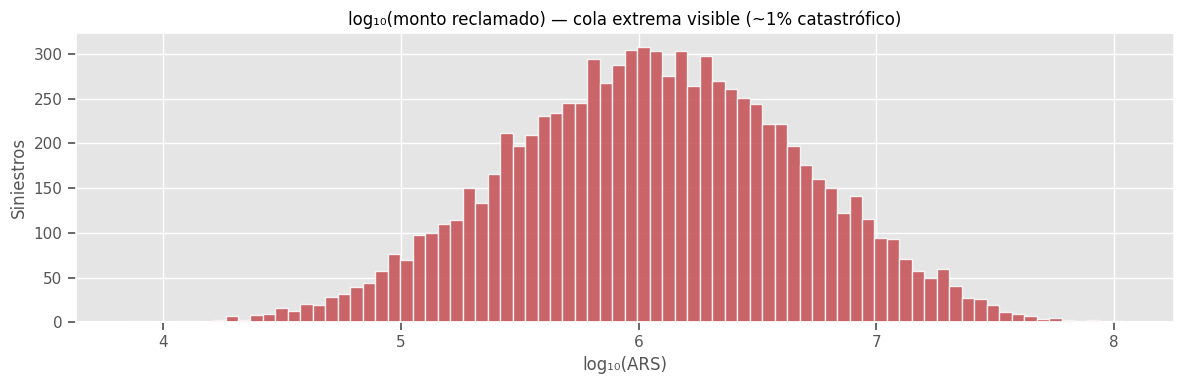

In [23]:

# ── Estacionalidad por tipo de daño ─────────────────────────────────────────
df_siniestros['mes_siniestro'] = df_siniestros['fecha_siniestro'].dt.month
NOMBRES_MES = {1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',
               7:'Jul',8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic'}

tipos_clave = ['Granizo', 'Choque', 'Robo total', 'Robo parcial']
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, tipo in zip(axes.flat, tipos_clave):
    sub = df_siniestros[df_siniestros['tipo_danio'] == tipo]
    conteo = sub.groupby('mes_siniestro').size().reindex(range(1, 13), fill_value=0)
    conteo.index = conteo.index.map(NOMBRES_MES)
    ax.bar(conteo.index, conteo.values, color='#4c72b0', alpha=0.85, edgecolor='white')
    ax.set_title(f'Estacionalidad — {tipo}')
    ax.set_xlabel('Mes'); ax.set_ylabel('Siniestros')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Distribución mensual por tipo de daño (Granizo: Oct–Mar  |  Choque: Jul–Ago  |  Robo: Dic–Feb)', y=1.01)
plt.tight_layout()
plt.show()

# Heatmap mes × tipo_danio
pivot_mes = (df_siniestros.groupby(['mes_siniestro', 'tipo_danio']).size()
             .unstack(fill_value=0))
pivot_mes.index = pivot_mes.index.map(NOMBRES_MES)
pivot_mes_pct = pivot_mes.div(pivot_mes.sum(axis=0), axis=1)
plt.figure(figsize=(13, 5))
sns.heatmap(pivot_mes_pct.T, annot=True, fmt='.2f', cmap='YlOrBr', linewidths=0.3)
plt.title('Distribución relativa: tipo de daño × mes del año')
plt.xlabel('Mes'); plt.ylabel('Tipo daño')
plt.tight_layout()
plt.show()

# ── Distribución de edad bimodal ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df_polizas['edad_asegurado'], bins=40, color='#4c72b0', alpha=0.85, edgecolor='white')
axes[0].set_title('Distribución edad (bimodal)')
axes[0].set_xlabel('Edad'); axes[0].set_ylabel('Pólizas')
axes[0].axvline(27, color='red',   linestyle='--', alpha=0.8, label='Pico joven (~27)')
axes[0].axvline(46, color='green', linestyle='--', alpha=0.8, label='Pico maduro (~46)')
axes[0].legend()

if 'tipo_vehiculo' in df_polizas.columns:
    palette_tv = {'Auto': '#4c72b0', 'Moto': '#dd8452', 'Camioneta': '#55a868'}
    for tv, color in palette_tv.items():
        sub = df_polizas.loc[df_polizas['tipo_vehiculo'] == tv, 'edad_asegurado']
        if len(sub) > 0:
            axes[1].hist(sub, bins=30, alpha=0.55, label=tv, color=color, density=True)
    axes[1].set_title('Edad por tipo de vehículo (densidad)')
    axes[1].set_xlabel('Edad'); axes[1].legend()
else:
    axes[1].set_visible(False)

# suma_asegurada con outliers
axes[2].hist(df_polizas['suma_asegurada'], bins=80, color='#dd8452', alpha=0.85, edgecolor='white')
axes[2].axvline(45_000_000, color='red', linestyle='--', alpha=0.8, label='Límite clipping (45M)')
n_outliers = (df_polizas['suma_asegurada'] > 45_000_000).sum()
axes[2].set_title(f'Suma asegurada — {n_outliers} outliers > 45M ARS')
axes[2].set_xlabel('ARS'); axes[2].legend()
plt.tight_layout()
plt.show()

# Cola extrema de siniestros
q99 = df_siniestros['monto_reclamado'].quantile(0.99)
n_extreme = (df_siniestros['monto_reclamado'] > df_siniestros['monto_reclamado'].median() * 10).sum()
print(f'P99 monto reclamado : ARS {q99:,.0f}')
print(f'Siniestros > 10× mediana: {n_extreme} ({n_extreme/len(df_siniestros)*100:.2f}%)')

plt.figure(figsize=(12, 4))
plt.hist(np.log10(df_siniestros['monto_reclamado'].clip(lower=1)), bins=80,
         color='#c44e52', alpha=0.85, edgecolor='white')
plt.title('log₁₀(monto reclamado) — cola extrema visible (~1% catastrófico)')
plt.xlabel('log₁₀(ARS)'); plt.ylabel('Siniestros')
plt.tight_layout()
plt.show()
